# Position and Direction model Training

Position and direction reconstruction training pipeline for the SBND detector.
Uses a reduced ResNet-18 architecture (~3M parameters) to predict neutrino vertex
position (X, Y, Z) and direction (dirY, dirZ) from PMT light images.


## 1. Setup and Configuration

In [1]:
import os, psutil
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

print("GPU:", gpus)
print(f"RAM libre: {psutil.virtual_memory().available/1e9:.1f} GB")

2026-04-10 15:54:29.284000: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-10 15:54:29.284107: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-10 15:54:29.285778: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-10 15:54:29.290706: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
RAM libre: 444.3 GB


2026-04-10 15:54:35.824664: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-10 15:54:35.884364: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-10 15:54:35.884795: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [112]:
import sys
sys.path.insert(0, '/exp/sbnd/app/users/svidales/larsoft_develop/srcs/sbndcode/sbndcode/NuIntNNOpReco/2-cnn-training-notebooks/')
import importlib, plot_style
importlib.reload(plot_style)
from plot_style import *

import os, time as _t, gc
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split

# Suppress TF C++ logs before importing TF (0=all, 1=no INFO, 2=no WARNING, 3=no ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import random


In [3]:
# ── Physical coordinate ranges and normalization ───────────────────────────
# Fixed detector boundaries ensure normalization is independent of the
# data distribution, avoiding bias from non-uniform event distributions.
PHYS_RANGES = {'x': (0., 200.), 'y': (-200., 200.), 'z': (0., 500.)}
# Target normalization ranges per axis: X,Z -> [0, 1]; Y -> [-1, 1]
TARGET_RANGES = {'x': (0., 1.), 'y': (-1., 1.), 'z': (0., 1.)}
COORD_CONFIG = {'ranges': PHYS_RANGES, 'target_ranges': TARGET_RANGES}  # stored for evaluation and export

def minmax_normalize(coords, ranges=PHYS_RANGES, target_ranges=TARGET_RANGES):
    """Normalize coordinates from physical cm to per-axis target range.
    X,Z -> [0, 1], Y -> [-1, 1]."""
    result = np.empty_like(coords, dtype=np.float32)
    for i, key in enumerate(['x', 'y', 'z']):
        lo, hi = ranges[key]
        tlo, thi = target_ranges[key]
        result[:, i] = (coords[:, i] - lo) / (hi - lo) * (thi - tlo) + tlo
    return result

def minmax_denormalize(coords_norm, ranges=PHYS_RANGES, target_ranges=TARGET_RANGES):
    """Inverse of minmax_normalize: per-axis target range back to physical cm."""
    result = np.empty_like(coords_norm, dtype=np.float32)
    for i, key in enumerate(['x', 'y', 'z']):
        lo, hi = ranges[key]
        tlo, thi = target_ranges[key]
        result[:, i] = (coords_norm[:, i] - tlo) / (thi - tlo) * (hi - lo) + lo
    return result

print(f'   * Physical ranges: {PHYS_RANGES}')
print(f'   * Target ranges:   {TARGET_RANGES}')


   * Physical ranges: {'x': (0.0, 200.0), 'y': (-200.0, 200.0), 'z': (0.0, 500.0)}
   * Target ranges:   {'x': (0.0, 1.0), 'y': (-1.0, 1.0), 'z': (0.0, 1.0)}


In [4]:
# ── Output directory (new folder per run) ───────────────────────────
from datetime import datetime
_ts = datetime.now().strftime('%Y%m%d_%H%M')
SAVE_DIR = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_' + _ts
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'>> Output directory: {SAVE_DIR}')

>> Output directory: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554


In [5]:
# ── Random seeds ─────────────────────────────────────────────────────────────
import random
import numpy as np
import tensorflow as tf

SEED = 777
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"   * Random seeds set (numpy, tf, random) = {SEED}")


   * Random seeds set (numpy, tf, random) = 777


In [221]:
ROOT_FILE = '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/AA_MC_samples/FallProd/FallProd_complete_dataset_v1603.root'

_t0 = _t.time()
print('Loading ROOT file...')
f_root = uproot.open(ROOT_FILE)

# ── 1. Labels ─────────────────────────────────────────────────────
lab = f_root['dataprep/labels/tree'].arrays(
    ['passed_filters', 'selected_tpc',
     'dEprom_x',  'dEprom_y',  'dEprom_z',
     'dEdir_x',   'dEdir_y',   'dEdir_z',
     'dEspread_x','dEspread_y','dEspread_z',
     'dEpca_lam1','dEpca_lam2','dEpca_lam3'], library='ak')

ok   = np.array(lab['passed_filters'], dtype=bool)
stpc = np.array(lab['selected_tpc'],   dtype=np.int32)
print(f'  passed_filters: {ok.sum():,} / {len(ok):,}  ({_t.time()-_t0:.1f}s)')

stpc_ok = stpc[ok]

def get_tpc_label(arr_ak, ok_mask, tpc_idx):
    ok_list = ak.to_list(arr_ak[ok_mask])
    return np.array([row[t] for row, t in zip(ok_list, tpc_idx)], dtype=np.float32)

dEpromx_final = get_tpc_label(lab['dEprom_x'],   ok, stpc_ok)
dEpromy_final = get_tpc_label(lab['dEprom_y'],   ok, stpc_ok)
dEpromz_final = get_tpc_label(lab['dEprom_z'],   ok, stpc_ok)
dEdirx        = get_tpc_label(lab['dEdir_x'],    ok, stpc_ok)
dEdiry        = get_tpc_label(lab['dEdir_y'],    ok, stpc_ok)
dEdirz        = get_tpc_label(lab['dEdir_z'],    ok, stpc_ok)
dEspreadx     = get_tpc_label(lab['dEspread_x'], ok, stpc_ok)
dEspready     = get_tpc_label(lab['dEspread_y'], ok, stpc_ok)
dEspreadz     = get_tpc_label(lab['dEspread_z'], ok, stpc_ok)
dEpca_lam1    = get_tpc_label(lab['dEpca_lam1'], ok, stpc_ok)
dEpca_lam2    = get_tpc_label(lab['dEpca_lam2'], ok, stpc_ok)
dEpca_lam3    = get_tpc_label(lab['dEpca_lam3'], ok, stpc_ok)
del lab
print(f'  Labels extracted: {len(dEpromx_final):,} events  ({_t.time()-_t0:.1f}s)')

# ── 2. Image grid dimensions and train/val/test split indices ─────────────────
# The split is computed HERE (before loading images) so that the normalization
# factor is derived exclusively from the training set — avoiding data leakage.
mx = f_root['dataprep/images/tree'].arrays(
    ['max_pe_uncoated', 'max_pe_coated', 'image_ny', 'image_nz'],
    entry_stop=int(ok.size), library='np')
ny = int(mx['image_ny'][ok][0])
nz = int(mx['image_nz'][ok][0])
n_ok = int(ok.sum())

# Early split on event indices (70 / 15 / 15)
from sklearn.model_selection import train_test_split as _tts
_idx_all = np.arange(n_ok)
idx_tr,  _idx_tmp = _tts(_idx_all, test_size=0.30, random_state=SEED)
idx_val, idx_te   = _tts(_idx_tmp, test_size=0.50, random_state=SEED)
idx_tr.sort(); idx_val.sort(); idx_te.sort()
print(f'  Split: train={len(idx_tr):,}  val={len(idx_val):,}  test={len(idx_te):,}')

# Max PE computed on training set only — no leakage from val/test
train_max_u = float(mx['max_pe_uncoated'][ok][idx_tr].max())
train_max_c = float(mx['max_pe_coated'][ok][idx_tr].max())
train_max   = max(train_max_u, train_max_c)  # joint max — matches inference module
del mx
print(f'  Train-set max PE — uncoated: {train_max_u:.1f}, coated: {train_max_c:.1f}')
print(f'  Joint normalisation factor  : {train_max:.1f}  ({_t.time()-_t0:.1f}s)')

# ── 3. Images — single pass, batched, joint-max norm, float32 ──────────────────
BATCH = 50_000
print(f'  Image grid: {ny} x {nz},  ok events: {n_ok:,}')
print(f'  Memory for images (float32): {n_ok*ny*nz*2*4/1e9:.2f} GB')

images   = np.empty((n_ok, ny, nz, 2), dtype=np.float32)
ev_start = 0
out_idx  = 0
for chunk in f_root['dataprep/images/tree'].iterate(
        ['image_uncoated', 'image_coated'], step_size=BATCH, library='ak'):
    n_chunk    = len(chunk['image_uncoated'])
    ok_chunk   = ok[ev_start:ev_start + n_chunk]
    n_ok_chunk = int(ok_chunk.sum())
    if n_ok_chunk > 0:
        u = ak.to_numpy(chunk['image_uncoated'][ok_chunk]).reshape(n_ok_chunk, ny, nz)
        c = ak.to_numpy(chunk['image_coated'][ok_chunk]).reshape(n_ok_chunk, ny, nz)
        images[out_idx:out_idx+n_ok_chunk, :, :, 0] = (u / train_max).astype(np.float32)
        images[out_idx:out_idx+n_ok_chunk, :, :, 1] = (c / train_max).astype(np.float32)
        del u, c
        out_idx += n_ok_chunk
    ev_start += n_chunk
    print(f'  {ev_start:,}/{ok.size}  ({out_idx:,} ok)  ({_t.time()-_t0:.1f}s)', end='\r')

gc.collect()
normalization_factor = train_max  # single joint factor (same for both channels)
print(f'\n  Images: {images.shape}  dtype={images.dtype}  ({_t.time()-_t0:.1f}s)')
print(f'\nTotal events loaded: {len(images):,}  —  {_t.time()-_t0:.1f}s')


Loading ROOT file...
  passed_filters: 554,528 / 1,365,732  (12.0s)
  Labels extracted: 554,528 events  (31.7s)
  Split: train=388,169  val=83,179  test=83,180
  Train-set max PE — uncoated: 6228.5, coated: 895992.6  (35.0s)
  Image grid: 59 x 70,  ok events: 554,528
  Memory for images (float32): 18.32 GB
  1,365,732/1365732  (554,528 ok)  (242.3s)
  Images: (554528, 59, 70, 2)  dtype=float32  (243.0s)

Total events loaded: 554,528  —  243.0s


**Example of an image normalized**

>> Example event #121958
   * Position: X=20.9 cm, Y=70.6 cm, Z=126.7 cm


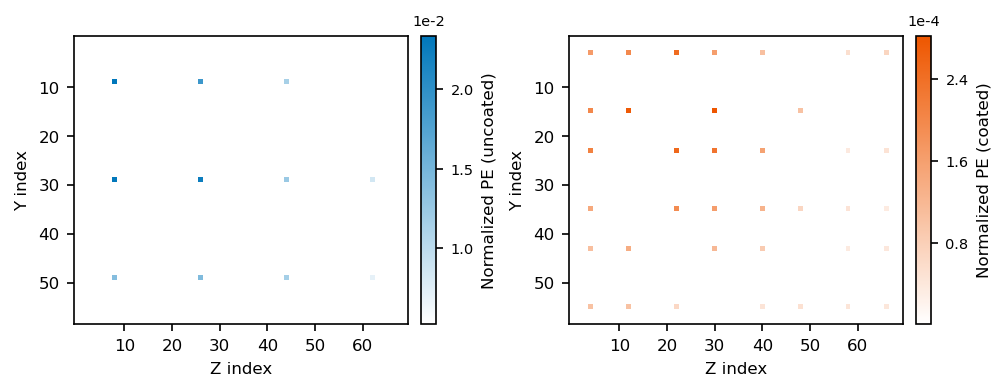


>> Image statistics:
   * Shape: (59, 70, 2)
   * Channel 0 (Uncoated): min=0.0000, max=0.0233, mean=0.0000
   * Channel 1 (Coated):   min=0.0000, max=0.0003, mean=0.0000
   * Non-zero pixels: 50 / 8260 (0.6%)


In [229]:
# Visualize example PE images for a random event
import math, colorsys
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib.colors import LinearSegmentedColormap, PowerNorm

def saturate(color, factor=1.8):
    """Boost saturation (HSV) keeping hue and value."""
    r, g, b, _ = mcolors.to_rgba(color)
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    return colorsys.hsv_to_rgb(h, min(1.0, s * factor), v)

cmap_u = LinearSegmentedColormap.from_list('uncoated', ['white', saturate(C_PRIMARY)])
cmap_c = LinearSegmentedColormap.from_list('coated',   ['white', saturate(C_SECONDARY)])

def nice_vmax(v):
    if v == 0: return 1
    mag = 10 ** math.floor(math.log10(v))
    return math.ceil(v / (mag / 2)) * (mag / 2)

np.random.seed(42)
event_idx = np.random.randint(0, len(images))
print(f'>> Example event #{event_idx}')
print(f'   * Position: X={dEpromx_final[event_idx]:.1f} cm, Y={dEpromy_final[event_idx]:.1f} cm, Z={dEpromz_final[event_idx]:.1f} cm')

img = images[event_idx]  # Shape: (59, 70, 2)

img_u = np.ma.masked_where(img[:, :, 0] == 0, img[:, :, 0])
img_c = np.ma.masked_where(img[:, :, 1] == 0, img[:, :, 1])

fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.5), constrained_layout=True)

for ax, data, cmap, label in zip(
        axes,
        [img_u, img_c],
        [cmap_u, cmap_c],
        ['Normalized PE (uncoated)', 'Normalized PE (coated)']):
    vmax = nice_vmax(float(data.max()))
    im = ax.imshow(data, cmap=cmap, aspect='auto', origin='upper')
    ax.set_xticks([10, 20, 30, 40, 50, 60])
    ax.set_yticks([10, 20, 30, 40, 50])
    ax.set_xlabel('Z index', fontsize=8)
    ax.set_ylabel('Y index', fontsize=8)
    ax.tick_params(labelsize=8)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(label, fontsize=8)
    cb.locator = MaxNLocator(nbins=4, min_n_ticks=3)
    dmax = float(data.max())
    exp = int(math.floor(math.log10(dmax))) if dmax > 0 else 0
    cb.formatter = FuncFormatter(lambda x, _, e=exp: f'{x/10**e:.1f}' if x != 0 else '0')
    cb.update_ticks()
    cb.ax.tick_params(labelsize=7)
    cb.ax.set_title(f'1e{exp:d}', fontsize=7, pad=5)

plt.savefig(f'{SAVE_DIR}/pe_images_example.png', dpi=500, bbox_inches='tight')
plt.savefig(f'{SAVE_DIR}/pe_images_example.pdf', bbox_inches='tight')
plt.show()

print(f'\n>> Image statistics:')
print(f'   * Shape: {img.shape}')
print(f'   * Channel 0 (Uncoated): min={img[:,:,0].min():.4f}, max={img[:,:,0].max():.4f}, mean={img[:,:,0].mean():.4f}')
print(f'   * Channel 1 (Coated):   min={img[:,:,1].min():.4f}, max={img[:,:,1].max():.4f}, mean={img[:,:,1].mean():.4f}')
print(f'   * Non-zero pixels: {np.count_nonzero(img)} / {img.size} ({100*np.count_nonzero(img)/img.size:.1f}%)')

## 4. Target Variable Preparation

In [8]:
# Prepare coordinates (use absolute x)
print(">> Preparing target variables...")

# Baricentro (dEprom)
x_abs = np.abs(np.array(dEpromx_final).flatten())
y = np.array(dEpromy_final).flatten()
z = np.array(dEpromz_final).flatten()

coordinates = np.column_stack((x_abs, y, z))
print(f"   * Coordinate ranges before standardization:")
print(f"     - X (abs): [{np.min(x_abs):.1f}, {np.max(x_abs):.1f}]")
print(f"     - Y: [{np.min(y):.1f}, {np.max(y):.1f}]")
print(f"     - Z: [{np.min(z):.1f}, {np.max(z):.1f}]")

# NOTE: min-max normalization with physical detector ranges is applied after
#       the train/val/test split (cell 12). Here we just store raw coordinates.
y_pos_raw = coordinates.copy()
print(f"\n   * Raw coordinates stored (standardization after split)")
print(f"   * Position target shape: {y_pos_raw.shape}")

# ========================================================================
# TARGET 2: Direction 2D in YZ plane (y_dir) - shape (N, 2)
# ========================================================================
dirx = np.array(dEdirx).flatten()
diry = np.array(dEdiry).flatten()
dirz = np.array(dEdirz).flatten()

print(f"\n   * PCA Direction 3D ranges:")
print(f"     - dirx: [{np.nanmin(dirx):.3f}, {np.nanmax(dirx):.3f}]")
print(f"     - diry: [{np.nanmin(diry):.3f}, {np.nanmax(diry):.3f}]")
print(f"     - dirz: [{np.nanmin(dirz):.3f}, {np.nanmax(dirz):.3f}]")

# Project onto YZ plane and normalize
# norm_yz_safe avoids division by zero for rare events nearly parallel to X axis;
# those events are kept in the dataset (w_dir will naturally down-weight them).
norm_yz = np.sqrt(diry**2 + dirz**2)
norm_yz_safe = np.maximum(norm_yz, 1e-6)
dir2d_y = diry / norm_yz_safe
dir2d_z = dirz / norm_yz_safe

y_dir = np.column_stack((dir2d_y, dir2d_z))  # (N, 2)

print(f"\n   * Direction 2D target (YZ plane):")
print(f"     - dir2d_y: [{np.min(dir2d_y):.3f}, {np.max(dir2d_y):.3f}]")
print(f"     - dir2d_z: [{np.min(dir2d_z):.3f}, {np.max(dir2d_z):.3f}]")

# Diagnostic: how many events are nearly parallel to X axis
n_degenerate = np.sum(norm_yz < 0.1)
print(f"\n   * Events with norm_yz < 0.1 (nearly along X): {n_degenerate} ({100*np.mean(norm_yz < 0.1):.2f}%) — kept")

# Filter only truly invalid values (-999 or NaN), not near-X-axis events
invalid_mask = (dirx == -999) | (diry == -999) | (dirz == -999) | \
               np.isnan(dirx) | np.isnan(diry) | np.isnan(dirz)
good_mask = ~invalid_mask
n_removed = int(np.sum(invalid_mask))
if n_removed > 0:
    print(f"\n   * Filtering {n_removed} invalid events (-999/NaN)...")
    y_pos_raw  = y_pos_raw[good_mask]
    y_dir      = y_dir[good_mask]
    images     = images[good_mask]
    # The split indices (idx_tr/val/te) were computed in the data-loading cell on
    # n_ok events. If events were removed here, those indices are stale — recompute.
    from sklearn.model_selection import train_test_split as _tts2
    _n_filtered = len(images)
    idx_tr,  _idx_tmp2 = _tts2(np.arange(_n_filtered), test_size=0.30, random_state=SEED)
    idx_val, idx_te    = _tts2(_idx_tmp2, test_size=0.50, random_state=SEED)
    idx_tr.sort(); idx_val.sort(); idx_te.sort()
    print(f"   * Remaining events: {_n_filtered:,}  — split recomputed")
else:
    print(f"\n   * No invalid events found — split indices unchanged")

# ========================================================================
# WEIGHT: Directionality from PCA eigenvalues (lam1 >= lam2 >= lam3)
# w_dir = lam1 / (lam1 + lam2 + lam3): fraction of variance along main axis
# Range: [1/3 isotropic shower] → [1 perfect track]
# ========================================================================
lam1 = np.array(dEpca_lam1).flatten()
lam2 = np.array(dEpca_lam2).flatten()
lam3 = np.array(dEpca_lam3).flatten()

if n_removed > 0:
    lam1 = lam1[good_mask]
    lam2 = lam2[good_mask]
    lam3 = lam3[good_mask]

lam_sum = lam1 + lam2 + lam3 + 1e-6
w_dir = lam1 / lam_sum   # ∈ [1/3, 1]

# Normalize so mean weight = 1, using training-set mean only (no leakage from val/test)
w_dir_train_mean = np.mean(w_dir[idx_tr])
w_dir = w_dir / (w_dir_train_mean + 1e-8)

print(f"\n   * Directionality weights from PCA eigenvalues (lam1/lam_sum):")
print(f"     - Range: [{np.min(w_dir):.3f}, {np.max(w_dir):.3f}]")
print(f"     - Train mean (normalization factor): {w_dir_train_mean:.4f}")
print(f"     - Mean after normalization: {np.mean(w_dir[idx_tr]):.3f} (train=1.0 by construction)")
print(f"     - Events with w > 1.5 (track-like): {100*np.mean(w_dir[idx_tr] > 1.5):.1f}% (train)")

print(f"\n>> Two separate models will be trained:")
print(f"   * Model 1: Position (ResNet-18, MSE loss) - min-max normalized targets")
print(f"   * Model 2: Direction 2D YZ (ResNet-18, sign-invariant angular loss)")

>> Preparing target variables...
   * Coordinate ranges before standardization:
     - X (abs): [0.6, 200.0]
     - Y: [-199.6, 199.3]
     - Z: [0.8, 500.0]

   * Raw coordinates stored (standardization after split)
   * Position target shape: (554528, 3)

   * PCA Direction 3D ranges:
     - dirx: [-1.000, 1.000]
     - diry: [-1.000, 1.000]
     - dirz: [0.000, 1.000]

   * Direction 2D target (YZ plane):
     - dir2d_y: [-1.000, 1.000]
     - dir2d_z: [0.000, 1.000]

   * Events with norm_yz < 0.1 (nearly along X): 1339 (0.24%) — kept

   * No invalid events found — split indices unchanged

   * Directionality weights from PCA eigenvalues (lam1/lam_sum):
     - Range: [0.435, 1.212]
     - Train mean (normalization factor): 0.8254
     - Mean after normalization: 1.000 (train=1.0 by construction)
     - Events with w > 1.5 (track-like): 0.0% (train)

>> Two separate models will be trained:
   * Model 1: Position (ResNet-18, MSE loss) - min-max normalized targets
   * Model 2: Direc

## 5. Train/Validation Split

In [9]:
# Split 70 / 15 / 15  (train / val / test)
# NOTE: idx_tr / idx_val / idx_te were already computed in the data-loading cell
#       (before image normalization) to avoid data leakage. Reused here.

# Combined array for label splitting (raw pos + dir + weight)
y_combined_raw = np.column_stack((y_pos_raw, y_dir, w_dir.reshape(-1, 1)))

N = len(y_combined_raw)
assert N == len(images), f"Mismatch: labels {N} vs images {len(images)}"

x_train = images[idx_tr];  x_val = images[idx_val];  x_test_set = images[idx_te]

# ── Min-max normalization with physical detector ranges ────────────────────────
# Uses fixed detector boundaries (not data statistics) to avoid distribution bias.
print(f">> Min-max normalization with physical detector ranges:")
print(f"   * X: [{PHYS_RANGES['x'][0]}, {PHYS_RANGES['x'][1]}] cm -> [0, 1]")
print(f"   * Y: [{PHYS_RANGES['y'][0]}, {PHYS_RANGES['y'][1]}] cm -> [-1, 1]")
print(f"   * Z: [{PHYS_RANGES['z'][0]}, {PHYS_RANGES['z'][1]}] cm -> [0, 1]")

# Normalize all positions using physical ranges
y_combined_raw[:, :3] = minmax_normalize(y_combined_raw[:, :3])

y_train = y_combined_raw[idx_tr]
y_val   = y_combined_raw[idx_val]
y_test_combined = y_combined_raw[idx_te]

n_train, n_val, n_test = len(idx_tr), len(idx_val), len(idx_te)
print(f"\nDataset splits:")
print(f"  Training:   {n_train:,} ({100*n_train/N:.1f}%)")
print(f"  Validation: {n_val:,}  ({100*n_val/N:.1f}%)")
print(f"  Test:       {n_test:,}  ({100*n_test/N:.1f}%)")
print(f"\nx_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}  (pos_norm[3] | dir2d[2] | w_dir[1])")

# Verify: normalized training targets should be in [-1, 1]
tr_pos = y_train[:, :3]
print(f"\n   * Normalized training pos range:")
for i, c in enumerate(['X', 'Y', 'Z']):
    print(f"     {c}: [{tr_pos[:,i].min():.4f}, {tr_pos[:,i].max():.4f}] (mean={tr_pos[:,i].mean():.4f})")

>> Min-max normalization with physical detector ranges:
   * X: [0.0, 200.0] cm -> [0, 1]
   * Y: [-200.0, 200.0] cm -> [-1, 1]
   * Z: [0.0, 500.0] cm -> [0, 1]

Dataset splits:
  Training:   388,169 (70.0%)
  Validation: 83,179  (15.0%)
  Test:       83,180  (15.0%)

x_train shape: (388169, 59, 70, 2)
y_train shape: (388169, 6)  (pos_norm[3] | dir2d[2] | w_dir[1])

   * Normalized training pos range:
     X: [0.0031, 1.0000] (mean=0.4870)
     Y: [-0.9978, 0.9965] (mean=0.0019)
     Z: [0.0016, 1.0000] (mean=0.5523)


## 6. Model Definition (ResNet-18 Architecture)

In [23]:
# Clear everything and restart model training from scratch
import gc
print(">> Clearing GPU memory and resetting model...")

# Clear Keras session completely
tf.keras.backend.clear_session()

# Force garbage collection
gc.collect()

# Delete existing model if it exists
try:
  del DirModel
  print("   * Deleted existing model")
except:
  print("   * No existing model to delete")

print(">> Memory and model cleared - ready for fresh training")

>> Clearing GPU memory and resetting model...
   * Deleted existing model
>> Memory and model cleared - ready for fresh training


**Position model — ResNet-18 (output: X, Y, Z)**


In [230]:
# Define reduced ResNet-18 architecture for position regression
def create_resnet18_model(input_shape, dropout_rate=0.3):
    """Reduced ResNet-18 for position regression (32->64->128->256, ~3M params).

    Basic blocks (3x3->3x3). Filter count halved vs standard ResNet-18
    to match the smaller input resolution (59x70 vs 224x224).
    (matching min-max normalization with physical detector ranges).
    """
    input_layer = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, kernel_size=7, strides=2, padding='same', use_bias=False)(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    def basic_block(inp, filters, stride=1, downsample=False):
        shortcut = inp
        x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(inp)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        if downsample:
            shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(inp)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)
        return x

    # Reduced ResNet-18 stages: 32->64->128->256
    x = basic_block(x, 32)
    x = basic_block(x, 32)
    x = basic_block(x, 64,  stride=2, downsample=True)
    x = basic_block(x, 64)
    x = basic_block(x, 128, stride=1, downsample=True)
    x = basic_block(x, 128)
    x = basic_block(x, 256, stride=1, downsample=True)
    x = basic_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(3)(x)

    return models.Model(inputs=input_layer, outputs=output)

print(">> create_resnet18_model defined (reduced ResNet-18: 32->64->128->256, ~3M params)")

>> create_resnet18_model defined (reduced ResNet-18: 32->64->128->256, ~3M params)


In [10]:
# Define standard ResNet-18 architecture (~11M params) for position regression
# Uses full filter sizes (64→128→256→512) with stride=1 in stages 3 & 4
# to preserve spatial resolution on the small 59×70 input.
def create_resnet18_full_model(input_shape, dropout_rate=0.2):
    """Standard ResNet-18 for position regression (~11M params).

    Full filter count (64→128→256→512). Stages 3 & 4 use stride=1
    instead of stride=2 to avoid collapsing the feature map on small inputs.
    """
    input_layer = layers.Input(shape=input_shape)

    # Stem
    x = layers.Conv2D(64, kernel_size=7, strides=2, padding='same', use_bias=False)(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    def basic_block(input_tensor, filters, stride=1, downsample=False):
        shortcut = input_tensor
        x = layers.Conv2D(filters, kernel_size=3, strides=stride, padding='same', use_bias=False)(input_tensor)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        if downsample:
            shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same', use_bias=False)(input_tensor)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)
        return x

    # Stage 1: 64 filters, stride=1
    x = basic_block(x, 64)
    x = basic_block(x, 64)

    # Stage 2: 128 filters, stride=2
    x = basic_block(x, 128, stride=2, downsample=True)
    x = basic_block(x, 128)

    # Stage 3: 256 filters, stride=1 (preserve resolution on small input)
    x = basic_block(x, 256, stride=1, downsample=True)
    x = basic_block(x, 256)

    # Stage 4: 512 filters, stride=1 (preserve resolution on small input)
    x = basic_block(x, 512, stride=1, downsample=True)
    x = basic_block(x, 512)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(3)(x)

    return models.Model(inputs=input_layer, outputs=output)

print(">> create_resnet18_full_model defined (~11M params)")

>> create_resnet18_full_model defined (~11M params)


**Direction model — ResNet-18 (output: dirY, dirZ)**


In [24]:
# =============================================================================
# DIRECTION MODEL DEFINITIONS
# =============================================================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler


# --- Loss function -----------------------------------------------------------

def angular_loss(y_true, y_pred):
    """Sign-invariant angular loss in radians using atan2 (numerically stable).

    atan2(|cross|, |dot|) gives angle in [0, pi/2], sign-invariant.
    Magnitudes of y_true / y_pred cancel out automatically.
    """
    dot   = tf.reduce_sum(y_true * y_pred, axis=-1)
    cross = y_true[:, 0] * y_pred[:, 1] - y_true[:, 1] * y_pred[:, 0]
    return tf.atan2(tf.abs(cross), tf.abs(dot))


# --- Model -------------------------------------------------------------------

def create_direction_model(input_shape, dropout_rate=0.3):
    """Reduced ResNet-18 direction model (32->64->128->256, ~3M params).

    Basic blocks (3x3->3x3). Head: Dense(128)->Dense(2).
    """
    input_layer = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, kernel_size=7, strides=2, padding='same', use_bias=False)(input_layer)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    def basic_block(inp, filters, stride=1, downsample=False):
        shortcut = inp
        x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(inp)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        if downsample:
            shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(inp)
            shortcut = layers.BatchNormalization()(shortcut)
        x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)
        return x

    # Reduced ResNet-18 stages: 32->64->128->256
    x = basic_block(x, 32)
    x = basic_block(x, 32)
    x = basic_block(x, 64,  stride=2, downsample=True)
    x = basic_block(x, 64)
    x = basic_block(x, 128, stride=1, downsample=True)
    x = basic_block(x, 128)
    x = basic_block(x, 256, stride=1, downsample=True)
    x = basic_block(x, 256)

    x = layers.GlobalAveragePooling2D()(x)

    # Direction head
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(2)(x)  # (dy, dz)

    return models.Model(inputs=input_layer, outputs=output)


print(">> Direction model functions defined:")
print("   * angular_loss      (atan2-based, sign-invariant, NaN-safe)")
print("   * create_direction_model (reduced ResNet-18: 32->64->128->256, ~3M params)")


>> Direction model functions defined:
   * angular_loss      (atan2-based, sign-invariant, NaN-safe)
   * create_direction_model (reduced ResNet-18: 32->64->128->256, ~3M params)


## 7. Training


### Position Training

In [ ]:
# =============================================================================
# TRAINING 1: POSITION MODEL
# =============================================================================
print("=" * 60)
print("   TRAINING 1: POSITION MODEL (ResNet-18 reduced, ~2.8M params)")
print("=" * 60)

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

POS_CONFIG = {
    'epochs': 40,
    'batch_size': 256,
    'patience': 6,
    'LRpatience': 3,
    'min_lr': 1e-7,
    'dropout_rate': 0.3,
    'learning_rate': 2e-4,
    'warmup_epochs': 2,
}

print(f"   * Seed: {SEED}")
print(f"   * Epochs: {POS_CONFIG['epochs']}")
print(f"   * Batch size: {POS_CONFIG['batch_size']}")
print(f"   * Patience: {POS_CONFIG['patience']}")
print(f"   * LR: {POS_CONFIG['learning_rate']}")
print(f"   * Warmup: {POS_CONFIG['warmup_epochs']} epochs")
print(f"   * Dropout: {POS_CONFIG['dropout_rate']}")

# Separate position targets (columns 0-2)
y_train_pos = y_train[:, :3]
y_val_pos   = y_val[:, :3]
print(f"\n   * Train: {y_train_pos.shape}, Val: {y_val_pos.shape}")

# Clean old checkpoint
pos_weights_file = '/tmp/weights_pos_model.keras'
if os.path.exists(pos_weights_file):
    os.remove(pos_weights_file)

input_shape = x_train.shape[1:]
PosModel = create_resnet18_model(input_shape, POS_CONFIG['dropout_rate'])
print(f"   * Parameters: {PosModel.count_params():,}")

# ── Linear warmup + ReduceLROnPlateau callback ───────────────────────────────
# Ramps LR from ~0 to target over warmup_epochs, then hands off to
# ReduceLROnPlateau for decay. Prevents large early gradients that cause
# the transient spike in validation loss.
class WarmupScheduler(tf.keras.callbacks.Callback):
    def __init__(self, target_lr, warmup_steps):
        super().__init__()
        self.target_lr = target_lr
        self.warmup_steps = warmup_steps
        self._step = 0
        self._warmup_done = False

    def on_train_batch_begin(self, batch, logs=None):
        if self._warmup_done:
            return
        self._step += 1
        if self._step <= self.warmup_steps:
            lr = self.target_lr * (self._step / self.warmup_steps)
            self.model.optimizer.learning_rate.assign(lr)
        else:
            self._warmup_done = True
            self.model.optimizer.learning_rate.assign(self.target_lr)

steps_per_epoch = int(np.ceil(len(y_train_pos) / POS_CONFIG['batch_size']))
warmup_steps = steps_per_epoch * POS_CONFIG['warmup_epochs']
print(f"   * Steps/epoch: {steps_per_epoch}, warmup steps: {warmup_steps}")

warmup_cb = WarmupScheduler(
    target_lr=POS_CONFIG['learning_rate'],
    warmup_steps=warmup_steps)

# ── Sub-epoch logging callback ────────────────────────────────────────────────
class SubEpochLogger(tf.keras.callbacks.Callback):
    def __init__(self, val_data, log_every=50, val_every=200, val_samples=8192,
                 val_weights=None):
        super().__init__()
        self.val_x, self.val_y = val_data
        self.val_weights = val_weights
        self.log_every   = log_every
        self.val_every   = val_every
        self.val_samples = min(val_samples, len(self.val_y))
        self.train_log = []
        self.val_log   = []
        self._batch_losses = []
        self._global_step  = 0
        self._steps_per_epoch = None

    def on_epoch_begin(self, epoch, logs=None):
        if self._steps_per_epoch is None:
            n_train = self.params.get('steps', None)
            if n_train is None:
                n_train = self.params.get('nb_sample', 0) // self.params.get('batch_size', 1)
            self._steps_per_epoch = max(n_train, 1)

    def on_train_batch_end(self, batch, logs=None):
        self._global_step += 1
        loss = logs.get('loss', None)
        if loss is not None:
            self._batch_losses.append(loss)

        if self._global_step % self.log_every == 0:
            avg = np.mean(self._batch_losses[-self.log_every:])
            frac_epoch = self._global_step / self._steps_per_epoch
            self.train_log.append((frac_epoch, float(avg)))

        if self._global_step % self.val_every == 0:
            idx = np.random.choice(len(self.val_y), self.val_samples, replace=False)
            if self.val_weights is not None:
                val_loss = self.model.evaluate(
                    self.val_x[idx], self.val_y[idx],
                    sample_weight=self.val_weights[idx],
                    verbose=0, batch_size=512)
            else:
                val_loss = self.model.evaluate(
                    self.val_x[idx], self.val_y[idx], verbose=0, batch_size=512)
            frac_epoch = self._global_step / self._steps_per_epoch
            self.val_log.append((frac_epoch, float(val_loss)))

sub_epoch_logger = SubEpochLogger(
    val_data=(x_val, y_val_pos),
    log_every=50, val_every=200, val_samples=8192)

pos_callbacks = [
    warmup_cb,
    ModelCheckpoint(pos_weights_file, monitor='val_loss', verbose=1,
                    save_best_only=True, mode='min'),
    EarlyStopping(monitor='val_loss', patience=POS_CONFIG['patience'],
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=POS_CONFIG['LRpatience'],
                      min_lr=POS_CONFIG['min_lr'], verbose=1),
    sub_epoch_logger,
]

PosModel.compile(
    optimizer=AdamW(learning_rate=1e-7, weight_decay=1e-4),
    loss=tf.keras.losses.Huber(delta=0.02)
)

print("\n>> Starting POSITION training...")
pos_history = PosModel.fit(
    x_train, y_train_pos,
    epochs=POS_CONFIG['epochs'],
    batch_size=POS_CONFIG['batch_size'],
    callbacks=pos_callbacks,
    validation_data=(x_val, y_val_pos),
    verbose=1,
    shuffle=True
)

print("\n>> Position training completed!")
best_epoch_pos = np.argmin(pos_history.history['val_loss'])
print(f"   * Best epoch: {best_epoch_pos + 1}")
print(f"   * Best val_loss: {pos_history.history['val_loss'][best_epoch_pos]:.6f}")
print(f"   * Sub-epoch points: {len(sub_epoch_logger.train_log)} train, {len(sub_epoch_logger.val_log)} val")

In [232]:
# Position model summary (rebuilt from definition for display)
from tensorflow.keras import layers, models
_tmp_pos = create_resnet18_model((59, 70, 2), dropout_rate=0.3)
_tmp_pos.summary()
del _tmp_pos

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 59, 70, 2) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 30, 35,    │      3,136 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 35,    │        128 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_34 (ReLU)     │ (None, 30, 35,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 15, 18,    │          0 │ re_lu_34[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 15, 18,    │      9,216 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_35 (ReLU)     │ (None, 15, 18,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 15, 18,    │      9,216 │ re_lu_35[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 15, 18,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_36 (ReLU)     │ (None, 15, 18,    │          0 │ add_16[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 15, 18,    │      9,216 │ re_lu_36[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_43[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_37 (ReLU)     │ (None, 15, 18,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 15, 18,    │      9,216 │ re_lu_37[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_44[0][0] 

 Total params: 2,802,883 (10.69 MB)

 Trainable params: 2,798,083 (10.67 MB)

 Non-trainable params: 4,800 (18.75 KB)

**Training loss vs epochs**

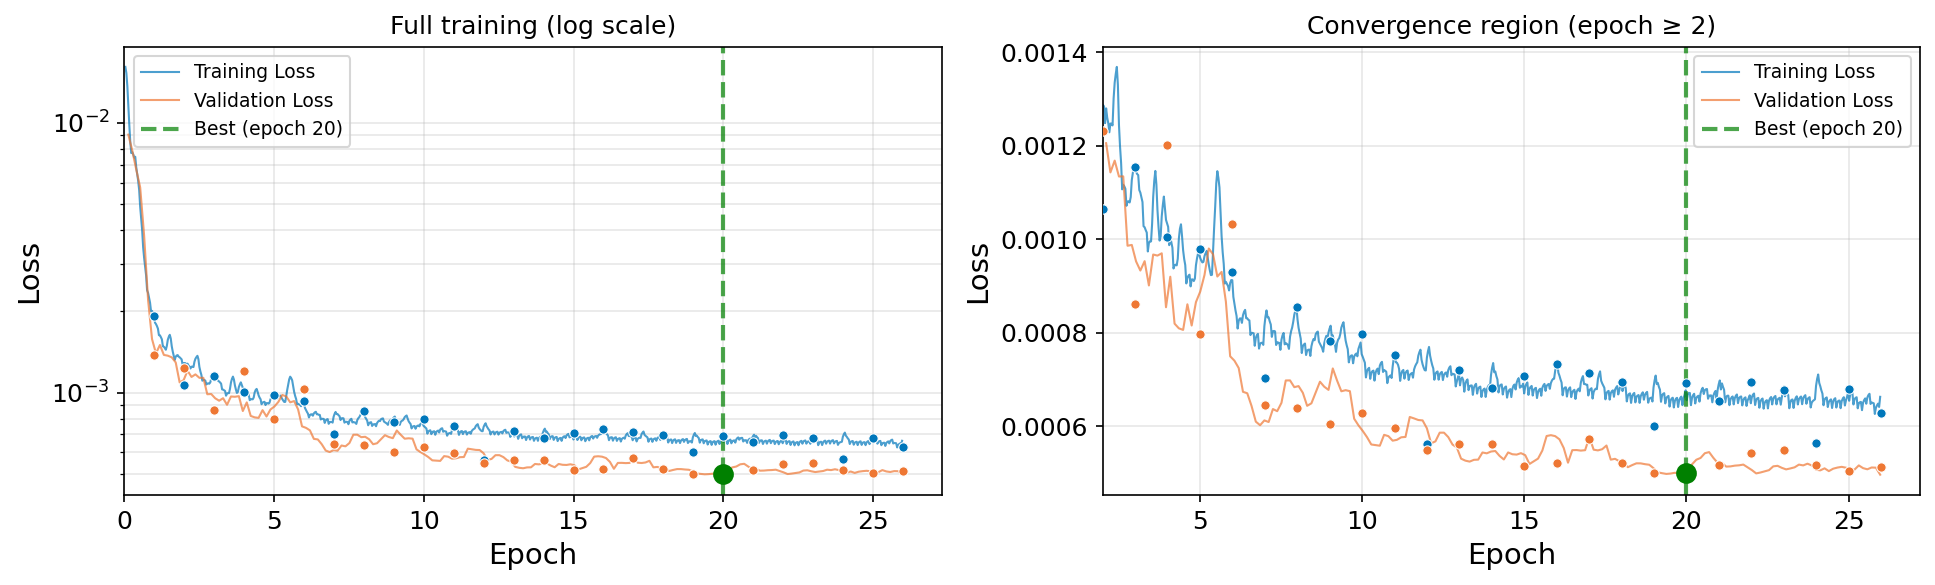

>> Position model: best epoch 20, val_loss=0.000499


In [219]:
# Plot POSITION training history (sub-epoch resolution)
def _rolling(y, w=4):
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 2: return y
    cs = np.concatenate(([0.0], np.cumsum(y)))
    half = w // 2
    idx = np.arange(n)
    lo = np.maximum(0, idx - half)
    hi = np.minimum(n, idx + half + 1)
    return (cs[hi] - cs[lo]) / (hi - lo)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epoch_val = pos_history.history['val_loss']
epoch_tr  = pos_history.history['loss']
n_epochs  = len(epoch_val)
best_epoch = np.argmin(epoch_val)
best_val_loss = epoch_val[best_epoch]

# ── Left panel: full view, log scale ──────────────────────────────────────────
if len(sub_epoch_logger.train_log) > 0:
    tr_epochs, tr_loss = zip(*sub_epoch_logger.train_log)
    tr_loss = _rolling(tr_loss)
    ax1.plot(tr_epochs, tr_loss, color=C_PRIMARY, linewidth=1.0, alpha=0.7, label='Training Loss')

if len(sub_epoch_logger.val_log) > 0:
    vl_epochs, vl_loss = zip(*sub_epoch_logger.val_log)
    vl_loss = _rolling(vl_loss)
    ax1.plot(vl_epochs, vl_loss, color=C_SECONDARY, linewidth=1.0, alpha=0.7, label='Validation Loss')

ax1.scatter(range(1, n_epochs+1), epoch_tr,  color=C_PRIMARY,   s=20, zorder=4, edgecolors='white', linewidths=0.5)
ax1.scatter(range(1, n_epochs+1), epoch_val, color=C_SECONDARY, s=20, zorder=4, edgecolors='white', linewidths=0.5)
ax1.axvline(x=best_epoch+1, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch+1})')
ax1.scatter([best_epoch+1], [best_val_loss], color='green', s=80, zorder=5)

ax1.set_yscale('log')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Full training (log scale)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim(left=0)

# ── Right panel: convergence zoom (skip transient, auto y-limits) ─────────────
SKIP_EPOCHS = 2  # skip initial transient for cleaner zoom

if len(sub_epoch_logger.train_log) > 0:
    tr_e, tr_l = np.array(tr_epochs), np.array(tr_loss)
    mask_tr = tr_e >= SKIP_EPOCHS
    if mask_tr.any():
        ax2.plot(tr_e[mask_tr], tr_l[mask_tr], color=C_PRIMARY, linewidth=1.0, alpha=0.7, label='Training Loss')

if len(sub_epoch_logger.val_log) > 0:
    vl_e, vl_l = np.array(vl_epochs), np.array(vl_loss)
    mask_vl = vl_e >= SKIP_EPOCHS
    if mask_vl.any():
        ax2.plot(vl_e[mask_vl], vl_l[mask_vl], color=C_SECONDARY, linewidth=1.0, alpha=0.7, label='Validation Loss')

ep_range = range(max(SKIP_EPOCHS, 1), n_epochs+1)
ax2.scatter(list(ep_range), [epoch_tr[i-1] for i in ep_range],  color=C_PRIMARY,   s=20, zorder=4, edgecolors='white', linewidths=0.5)
ax2.scatter(list(ep_range), [epoch_val[i-1] for i in ep_range], color=C_SECONDARY, s=20, zorder=4, edgecolors='white', linewidths=0.5)

ax2.axvline(x=best_epoch+1, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch+1})')
ax2.scatter([best_epoch+1], [best_val_loss], color='green', s=80, zorder=5)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title(f'Convergence region (epoch ≥ {SKIP_EPOCHS})')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(left=SKIP_EPOCHS)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/pos_training_history.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.savefig(f'{SAVE_DIR}/pos_training_history.pdf', bbox_inches='tight')
plt.show()

print(f">> Position model: best epoch {best_epoch+1}, val_loss={best_val_loss:.6f}")

In [14]:
# ── Quick position bias check on validation set (Gaussian fit per coordinate) ─
print(">> Position bias on validation set — Gaussian fit")

from scipy.optimize import curve_fit as _curve_fit

def _gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def _fit_gauss(diff, rng=150, nb=150):
    cnt, edges = np.histogram(diff, bins=nb, range=(-rng, rng))
    cx = (edges[:-1] + edges[1:]) / 2
    peak = cnt.max(); mu0 = cx[cnt.argmax()]
    ab = cx[cnt >= peak / 2]
    s0 = (ab[-1] - ab[0]) / 2.35 if len(ab) > 1 else 20.0
    try:
        popt, _ = _curve_fit(_gauss, cx, cnt, p0=[peak, mu0, s0],
                             bounds=([0, -rng, 0.5], [np.inf, rng, rng]), maxfev=5000)
        return popt[1], abs(popt[2])
    except Exception:
        return float(np.mean(diff)), float(np.std(diff))

_pred_norm = PosModel.predict(x_val, verbose=0)
_true_cm   = minmax_denormalize(y_val[:, :3])
_pred_cm   = minmax_denormalize(_pred_norm)
_diff      = _pred_cm - _true_cm   # Reco - True

print(f"\n   {'Coord':<6} {'μ (cm)':>10} {'σ (cm)':>10}")
print(f"   {'─'*28}")
for _i, _c in enumerate(['X', 'Y', 'Z']):
    _mu, _sig = _fit_gauss(_diff[:, _i])
    print(f"   {_c:<6} {_mu:>+10.2f} {_sig:>10.2f}")
print(f"\n   3D mean dist: {np.mean(np.linalg.norm(_diff, axis=1)):.1f} cm")

>> Position bias on validation set — Gaussian fit

   Coord      μ (cm)     σ (cm)
   ────────────────────────────
   X           -0.36       5.26
   Y           +0.83       6.68
   Z           +0.61       7.65

   3D mean dist: 18.0 cm


In [15]:
# Export Position model for inference
import json
import gc

print(">> Exporting Position model for inference...")

# Convert numpy types to native Python types for JSON serialization
def convert_numpy_types(obj):
  if isinstance(obj, np.ndarray):
   return obj.tolist()
  elif isinstance(obj, (np.float32, np.float64)):
   return float(obj)
  elif isinstance(obj, (np.int32, np.int64)):
   return int(obj)
  elif isinstance(obj, dict):
   return {key: convert_numpy_types(value) for key, value in obj.items()}
  elif isinstance(obj, list):
   return [convert_numpy_types(item) for item in obj]
  return obj

# Base export path
from datetime import datetime
date_str = datetime.now().strftime('%m%d')
n_events = len(y_train)
n_str = f"{n_events//1000}k" if n_events >= 1000 else str(n_events)
base_export = f"{SAVE_DIR}/models/v{date_str}_trained_w_{n_str}"

# ========================================================================
# Export POSITION model
# ========================================================================
pos_export_path = base_export + "_position"
os.makedirs(pos_export_path, exist_ok=True)

pos_model_save_path = os.path.join(pos_export_path, 'saved_model')
PosModel.export(pos_model_save_path)
# Save normalization parameters for inference (min-max with physical ranges)
pos_config = {
    'normalization': {
        'type': 'minmax',
        'ranges': {k: list(v) for k, v in PHYS_RANGES.items()},
    },
    'training_events': len(y_train),
    'validation_events': len(y_val),
    'best_val_loss': float(min(pos_history.history['val_loss'])),
}
pos_config_file = os.path.join(pos_export_path, 'inference_config.json')
with open(pos_config_file, 'w') as f:
    json.dump(convert_numpy_types(pos_config), f, indent=2)

print(f"   * Position model exported to: {pos_export_path}")
print(f"   * Normalization: min-max with ranges {PHYS_RANGES}")

>> Exporting Position model for inference...
INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554/models/v0410_trained_w_388k_position/saved_model/assets


INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554/models/v0410_trained_w_388k_position/saved_model/assets


Saved artifact at '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554/models/v0410_trained_w_388k_position/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 59, 70, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139778515886400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139778515860144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139778515880768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139778515888512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139778515884992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139778515850992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139778515849408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139778515851520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139778515845888: TensorSpec(s

### Direction Training

In [27]:
# =============================================================================
# TRAINING 2: DIRECTION MODEL (reduced ResNet-18, 2D YZ, sign-invariant angular loss)
# =============================================================================
print("=" * 60)
print("   TRAINING 2: DIRECTION MODEL (reduced ResNet-18, 2D YZ)")
print("=" * 60)

import os
import numpy as np
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

DIR_CONFIG = {
    'epochs': 40,
    'batch_size': 128,
    'patience': 6,
    'min_lr': 1e-7,
    'dropout_rate': 0.3,
    'learning_rate': 3e-4,
    'LRpatience': 5,
    'warmup_epochs': 2,
}

print(f"   * Epochs: {DIR_CONFIG['epochs']}")
print(f"   * Batch size: {DIR_CONFIG['batch_size']}")
print(f"   * Patience: {DIR_CONFIG['patience']}")
print(f"   * LR: {DIR_CONFIG['learning_rate']}")
print(f"   * Loss: Angular loss (angle in radians, weighted by dEspread elongation)")
print(f"   * Dropout: {DIR_CONFIG['dropout_rate']}")

# Separate direction targets (2D: columns 3-4)
y_train_dir = y_train[:, 3:5]
y_val_dir = y_val[:, 3:5]
print(f"\n   * Train: {y_train_dir.shape}, Val: {y_val_dir.shape}")

# Extract directionality weights (column 5)
w_train_dir = y_train[:, 5]
w_val_dir   = y_val[:, 5]
print(f"   * Direction weights: train mean={np.mean(w_train_dir):.3f}, val mean={np.mean(w_val_dir):.3f}")

# Clean old checkpoint
dir_weights_file = '/tmp/weights_dir_model.keras'
if os.path.exists(dir_weights_file):
    os.remove(dir_weights_file)

# input_shape from training data (in case position model cell was not run)
input_shape = x_train.shape[1:]
print(f"   * Input shape: {input_shape}")

# Create direction model
DirModel = create_direction_model(input_shape, DIR_CONFIG['dropout_rate'])
print(f"   * Parameters: {DirModel.count_params():,}")

# Linear warmup scheduler (same WarmupScheduler class from position cell)
steps_per_epoch_dir = int(np.ceil(len(y_train_dir) / DIR_CONFIG['batch_size']))
warmup_steps_dir = steps_per_epoch_dir * DIR_CONFIG['warmup_epochs']
print(f"   * Steps/epoch: {steps_per_epoch_dir}, warmup steps: {warmup_steps_dir}")

warmup_cb_dir = WarmupScheduler(
    target_lr=DIR_CONFIG['learning_rate'],
    warmup_steps=warmup_steps_dir)

# Sub-epoch logger for direction (same class as position model)
sub_epoch_logger_dir = SubEpochLogger(
    val_data=(x_val, y_val_dir),
    log_every=50, val_every=200, val_samples=8192,
    val_weights=w_val_dir)

# Callbacks
dir_callbacks = [
    warmup_cb_dir,
    ModelCheckpoint(dir_weights_file, monitor='val_loss', verbose=1,
                    save_best_only=True, mode='min'),
    EarlyStopping(monitor='val_loss', patience=DIR_CONFIG['patience'],
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=DIR_CONFIG['LRpatience'],
                      min_lr=DIR_CONFIG['min_lr'], verbose=1),
    sub_epoch_logger_dir,
]

# Compile — clipnorm=1.0 kept for direction model: angular_loss uses arccos
# whose gradients can spike near domain boundaries (|dot| ~ 1)
DirModel.compile(
    optimizer=AdamW(learning_rate=1e-7,
                    weight_decay=1e-4, clipnorm=1.0),
    loss=angular_loss
)

# Train
print("\n>> Starting DIRECTION training...")
dir_history = DirModel.fit(
    x_train, y_train_dir,
    sample_weight=w_train_dir,
    epochs=DIR_CONFIG['epochs'],
    batch_size=DIR_CONFIG['batch_size'],
    callbacks=dir_callbacks,
    validation_data=(x_val, y_val_dir, w_val_dir),
    verbose=1,
    shuffle=True
)

print("\n>> Direction training completed!")
best_epoch_dir = np.argmin(dir_history.history['val_loss'])
print(f"   * Best epoch: {best_epoch_dir + 1}")
print(f"   * Best val_loss: {dir_history.history['val_loss'][best_epoch_dir]:.6f} rad")
print(f"   * Best val_loss: {np.degrees(dir_history.history['val_loss'][best_epoch_dir]):.2f} deg")
print(f"   * Sub-epoch points: {len(sub_epoch_logger_dir.train_log)} train, {len(sub_epoch_logger_dir.val_log)} val")

   TRAINING 2: DIRECTION MODEL (reduced ResNet-18, 2D YZ)
   * Epochs: 40
   * Batch size: 128
   * Patience: 8
   * LR: 0.0003
   * Loss: Angular loss (angle in radians, weighted by dEspread elongation)
   * Dropout: 0.3

   * Train: (388169, 2), Val: (83179, 2)
   * Direction weights: train mean=1.000, val mean=1.001
   * Input shape: (59, 70, 2)
   * Parameters: 2,835,266
   * Steps/epoch: 3033, warmup steps: 6066

>> Starting DIRECTION training...
Epoch 1/40
3033/3033 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6530
Epoch 1: val_loss improved from None to 0.63232, saving model to /tmp/weights_dir_model.keras
3033/3033 ━━━━━━━━━━━━━━━━━━━━ 87s 24ms/step - loss: 0.6417 - val_loss: 0.6323 - learning_rate: 1.5000e-04
Epoch 2/40
3031/3033 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.6334
Epoch 2: val_loss improved from 0.63232 to 0.63028, saving model to /tmp/weights_dir_model.keras
3033/3033 ━━━━━━━━━━━━━━━━━━━━ 63s 21ms/step - loss: 0.6303 - val_loss: 0.6303 - learning_rate: 3.0000e-04

In [233]:
# Direction model summary (rebuilt from definition for display)
_tmp_dir = create_direction_model((59, 70, 2), dropout_rate=0.3)
_tmp_dir.summary()
del _tmp_dir

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 59, 70, 2) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 30, 35,    │      3,136 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 35,    │        128 │ conv2d_60[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_51 (ReLU)     │ (None, 30, 35,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 15, 18,    │          0 │ re_lu_51[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 15, 18,    │      9,216 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_61[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_52 (ReLU)     │ (None, 15, 18,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 15, 18,    │      9,216 │ re_lu_52[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_62[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 15, 18,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_53 (ReLU)     │ (None, 15, 18,    │          0 │ add_24[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 15, 18,    │      9,216 │ re_lu_53[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_54 (ReLU)     │ (None, 15, 18,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 15, 18,    │      9,216 │ re_lu_54[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 18,    │        128 │ conv2d_64[0][0] 

 Total params: 2,835,266 (10.82 MB)

 Trainable params: 2,830,466 (10.80 MB)

 Non-trainable params: 4,800 (18.75 KB)

**Training loss vs epochs**

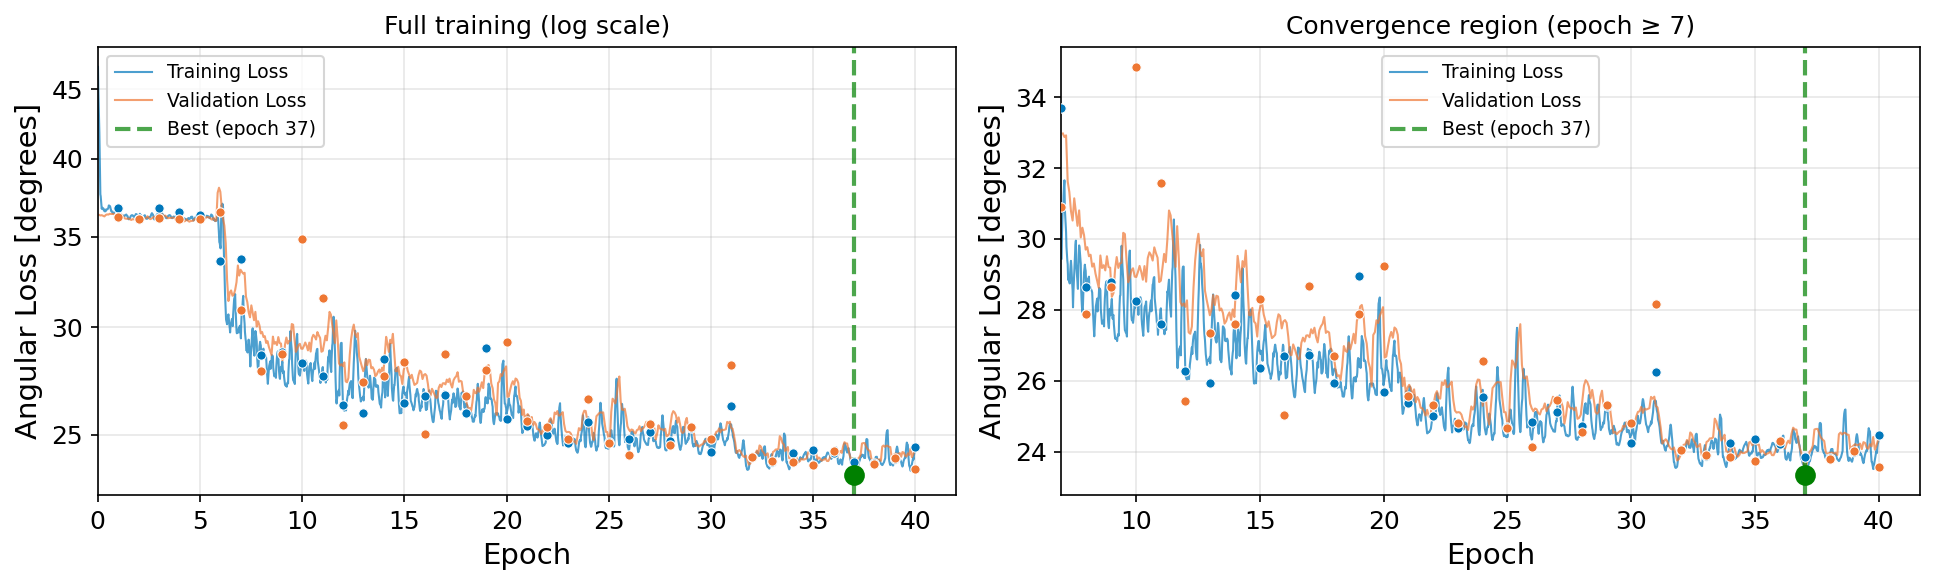

>> Direction model: best epoch 37, val_loss=23.35 deg


In [218]:
# Plot DIRECTION training history (sub-epoch resolution, mirrors position plot)
from matplotlib.ticker import FixedLocator, FuncFormatter

def _rolling(y, w=6):
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 2: return y
    cs = np.concatenate(([0.0], np.cumsum(y)))
    half = w // 2
    idx = np.arange(n)
    lo = np.maximum(0, idx - half)
    hi = np.minimum(n, idx + half + 1)
    return (cs[hi] - cs[lo]) / (hi - lo)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epoch_val_d = np.degrees(dir_history.history['val_loss'])
epoch_tr_d  = np.degrees(dir_history.history['loss'])
n_epochs_d  = len(epoch_val_d)
best_epoch_dir = int(np.argmin(epoch_val_d))
best_val_dir   = epoch_val_d[best_epoch_dir]

# ── Left panel: full view, log scale ─────────────────────────────────────
if len(sub_epoch_logger_dir.train_log) > 0:
    tr_e_d, tr_l_d = zip(*sub_epoch_logger_dir.train_log)
    tr_e_d = np.array(tr_e_d)
    tr_l_d = _rolling(np.degrees(tr_l_d))
    ax1.plot(tr_e_d, tr_l_d, color=C_PRIMARY, linewidth=1.0, alpha=0.7, label='Training Loss')

if len(sub_epoch_logger_dir.val_log) > 0:
    vl_e_d, vl_l_d = zip(*sub_epoch_logger_dir.val_log)
    vl_e_d = np.array(vl_e_d)
    vl_l_d = _rolling(np.degrees(vl_l_d))
    ax1.plot(vl_e_d, vl_l_d, color=C_SECONDARY, linewidth=1.0, alpha=0.7, label='Validation Loss')

ax1.scatter(range(1, n_epochs_d+1), epoch_tr_d,  color=C_PRIMARY,   s=20, zorder=4, edgecolors='white', linewidths=0.5)
ax1.scatter(range(1, n_epochs_d+1), epoch_val_d, color=C_SECONDARY, s=20, zorder=4, edgecolors='white', linewidths=0.5)
ax1.axvline(x=best_epoch_dir+1, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch_dir+1})')
ax1.scatter([best_epoch_dir+1], [best_val_dir], color='green', s=80, zorder=5)

ax1.set_yscale('log')
ax1.yaxis.set_major_locator(FixedLocator([20, 25, 30, 35, 40, 45, 50]))
ax1.yaxis.set_minor_locator(FixedLocator([]))
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Angular Loss [degrees]')
ax1.set_title('Full training (log scale)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xlim(left=0)

# ── Right panel: convergence zoom (skip transient, auto y-limits) ─────────────
SKIP_EPOCHS = 7  # skip plateau + warmup transient for cleaner zoom

if len(sub_epoch_logger_dir.train_log) > 0:
    mask_tr = tr_e_d >= SKIP_EPOCHS
    if mask_tr.any():
        ax2.plot(tr_e_d[mask_tr], tr_l_d[mask_tr], color=C_PRIMARY, linewidth=1.0, alpha=0.7, label='Training Loss')

if len(sub_epoch_logger_dir.val_log) > 0:
    mask_vl = vl_e_d >= SKIP_EPOCHS
    if mask_vl.any():
        ax2.plot(vl_e_d[mask_vl], vl_l_d[mask_vl], color=C_SECONDARY, linewidth=1.0, alpha=0.7, label='Validation Loss')

ep_range = range(max(SKIP_EPOCHS, 1), n_epochs_d+1)
ax2.scatter(list(ep_range), [epoch_tr_d[i-1] for i in ep_range],  color=C_PRIMARY,   s=20, zorder=4, edgecolors='white', linewidths=0.5)
ax2.scatter(list(ep_range), [epoch_val_d[i-1] for i in ep_range], color=C_SECONDARY, s=20, zorder=4, edgecolors='white', linewidths=0.5)

ax2.axvline(x=best_epoch_dir+1, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_epoch_dir+1})')
ax2.scatter([best_epoch_dir+1], [best_val_dir], color='green', s=80, zorder=5)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Angular Loss [degrees]')
ax2.set_title(f'Convergence region (epoch ≥ {SKIP_EPOCHS})')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(left=SKIP_EPOCHS)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/dir_training_history.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.savefig(f'{SAVE_DIR}/dir_training_history.pdf', bbox_inches='tight')
plt.show()

print(f">> Direction model: best epoch {best_epoch_dir+1}, val_loss={best_val_dir:.2f} deg")

## 8. Model Export


In [48]:
# ========================================================================
# Export DIRECTION model
# ========================================================================
import json
from datetime import datetime
date_str = datetime.now().strftime('%m%d')
n_events = len(y_train)
n_str = f"{n_events//1000}k" if n_events >= 1000 else str(n_events)
base_export = f"{SAVE_DIR}/models/v{date_str}_trained_w_{n_str}"

dir_export_path = base_export + "_direction_2d"
os.makedirs(dir_export_path, exist_ok=True)

dir_model_save_path = os.path.join(dir_export_path, 'saved_model')
DirModel.export(dir_model_save_path)
print(f"   * Direction model exported to: {dir_export_path}")

# ========================================================================
# Save direction model config (metadata for inference)
# ========================================================================
inference_config = {
    'models': {
        'direction_2d': {
            'path': dir_model_save_path,
            'output': '2 (dirY, dirZ normalized, YZ plane)',
            'loss': 'angular_loss (atan2-based, sign-invariant)',
            'epochs_trained': len(dir_history.history['loss']),
            'best_val_loss_rad': float(min(dir_history.history['val_loss'])),
            'best_val_loss_deg': float(np.degrees(min(dir_history.history['val_loss']))),
        }
    },
    'training_events': len(y_train),
    'validation_events': len(y_val),
}

config_file = os.path.join(dir_export_path, 'inference_config.json')
with open(config_file, 'w') as f:
    json.dump(inference_config, f, indent=2)

print(f">> Export completed:")
print(f"   * Direction: {dir_export_path}")
print(f"   * Trained on {len(y_train):,} events")
print(f"   * Best val_loss: {min(dir_history.history['val_loss']):.4f} rad = {np.degrees(min(dir_history.history['val_loss'])):.2f} deg")


INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554/models/v0411_trained_w_388k_direction_2d/saved_model/assets


INFO:tensorflow:Assets written to: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554/models/v0411_trained_w_388k_direction_2d/saved_model/assets


Saved artifact at '/exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554/models/v0411_trained_w_388k_direction_2d/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 59, 70, 2), dtype=tf.float32, name='keras_tensor_72')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139779199471984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139779344694992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139779199477440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139779310090752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139779311661680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139779328183456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139779328190144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139779328190496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139779328186800: Tenso

## 9. Inference


In [49]:

# ========================================================================
# Load saved models from disk (for inference without retraining)
# ========================================================================
import tensorflow as tf
import os

import glob as _glob
_pos_dirs = sorted(_glob.glob(f'{SAVE_DIR}/models/*_position/saved_model'))
_dir_dirs = sorted(_glob.glob(f'{SAVE_DIR}/models/*_direction_2d/saved_model'))
pos_model_path = _pos_dirs[-1] if _pos_dirs else None
dir_model_path = _dir_dirs[-1] if _dir_dirs else None
print(f">> Auto-detected model paths:")
print(f"   pos: {pos_model_path}")
print(f"   dir: {dir_model_path}")

def _make_predict_fn(model_path):
    """Load a SavedModel and return a predict(x) -> np.ndarray function."""
    raw = tf.saved_model.load(model_path)
    infer = raw.signatures['serving_default']
    # Get the input/output key names from the signature
    input_key  = list(infer.structured_input_signature[1].keys())[0]
    output_key = list(infer.structured_outputs.keys())[0]
    def predict(x):
        x_tensor = tf.constant(x, dtype=tf.float32)
        result = infer(**{input_key: x_tensor})
        return result[output_key].numpy()
    return predict

# --- Position model ---
if pos_model_path and os.path.exists(pos_model_path):
    _pos_predict_fn = _make_predict_fn(pos_model_path)
    class _PosWrapper:
        def predict(self, x): return _pos_predict_fn(x)
    PosModel = _PosWrapper()
    print(f">> Position model loaded from: {pos_model_path}")
    print(f"   * Input:  (N, 59, 70, 2)  |  Output: (N, 3) — (x, y, z scaled)")
else:
    print(f">> WARNING: position model not found at {pos_model_path}")
    print(f"   Using in-memory PosModel instead.")

# --- Direction model ---
if dir_model_path and os.path.exists(dir_model_path):
    _dir_predict_fn = _make_predict_fn(dir_model_path)
    class _DirWrapper:
        def predict(self, x): return _dir_predict_fn(x)
    DirModel = _DirWrapper()
    print(f">> Direction model loaded from: {dir_model_path}")
    print(f"   * Input:  (N, 59, 70, 2)  |  Output: (N, 2) — (dirY, dirZ)")
else:
    print(f">> WARNING: direction model not found at {dir_model_path}")
    print(f"   Using in-memory DirModel instead.")


>> Auto-detected model paths:
   pos: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554/models/v0410_trained_w_388k_position/saved_model
   dir: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554/models/v0411_trained_w_388k_direction_2d/saved_model
>> Position model loaded from: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554/models/v0410_trained_w_388k_position/saved_model
   * Input:  (N, 59, 70, 2)  |  Output: (N, 3) — (x, y, z scaled)
>> Direction model loaded from: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554/models/v0411_trained_w_388k_direction_2d/saved_model
   * Input:  (N, 59, 70, 2)  |  Output: (N, 2) — (dirY, dirZ)


In [215]:

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import math

BIAS_RANGE  = 200   # cm (for Gaussian fit range)
BIAS_ZOOM   = 60    # cm (for plot x-axis)
NBINS       = 200

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def fit_pos_residuals(diff, res_range=BIAS_RANGE, nbins=NBINS, n_sigma=2.5, n_iter=3, density=False):
    """Iterative Gaussian fit on the core of the residual distribution."""
    bins = np.linspace(-res_range, res_range, nbins + 1)
    cnt, edges = np.histogram(diff, bins=bins, density=density)
    cx = (edges[:-1] + edges[1:]) / 2
    peak  = cnt.max()
    mu0   = cx[cnt.argmax()]
    above = cx[cnt >= peak / 2]
    sig0  = (above[-1] - above[0]) / 2.35 if len(above) > 1 else 20.0
    popt = [peak, mu0, sig0]
    for _ in range(n_iter):
        mu_c, sig_c = popt[1], abs(popt[2])
        lo = max(mu_c - n_sigma * sig_c, -res_range)
        hi = min(mu_c + n_sigma * sig_c,  res_range)
        mask = (cx >= lo) & (cx <= hi) & (cnt > 0)
        if mask.sum() < 5:
            break
        try:
            popt, _ = curve_fit(gaussian, cx[mask], cnt[mask], p0=popt,
                                bounds=([0, -res_range, 0.1], [np.inf, res_range, res_range]),
                                maxfev=10000)
        except Exception:
            break
    return popt


def evaluate_models(x_data, y_data, set_label, save_prefix):
    """Full evaluation of position + direction models on a given dataset."""
    save_dir = SAVE_DIR

    # ── Predictions ───────────────────────────────────────────────────────────
    print(f">> Making predictions on {set_label.lower()} with both models...")
    pos_pred_norm  = PosModel.predict(x_data)
    pos_true_norm  = y_data[:, :3]
    dir2d_pred_raw = DirModel.predict(x_data)
    dir2d_true_raw = y_data[:, 3:5]

    dir2d_pred = dir2d_pred_raw / (np.linalg.norm(dir2d_pred_raw, axis=1, keepdims=True) + 1e-8)
    dir2d_true = dir2d_true_raw / (np.linalg.norm(dir2d_true_raw, axis=1, keepdims=True) + 1e-8)

    # Denormalize positions from [-1,1] back to physical cm
    pos_pred = minmax_denormalize(pos_pred_norm)
    pos_true = minmax_denormalize(pos_true_norm)

    N = len(x_data)
    pos_errors = pos_pred - pos_true
    dist_3d = np.linalg.norm(pos_errors, axis=1)

    cross = dir2d_true[:, 0] * dir2d_pred[:, 1] - dir2d_true[:, 1] * dir2d_pred[:, 0]
    dot   = np.sum(dir2d_true * dir2d_pred, axis=1)
    angle_err = np.degrees(np.arctan2(np.abs(cross), np.abs(dot)))

    print(f"   Predictions: {N:,} events")
    print(f"   Position  — mean 3D dist: {np.mean(dist_3d):.1f} cm")
    print(f"   Direction — median error:  {np.median(angle_err):.1f} deg")

    # ══════════════════════════════════════════════════════════════════════════
    # PLOT 1: Position (2x3) — Reco vs Truth (top) + Bias (bottom)
    # ══════════════════════════════════════════════════════════════════════════
    pos_names    = ['X', 'Y', 'Z']
    coord_units  = ['cm', 'cm', 'cm']
    coord_limits = [(0, 200), (-200, 200), (0, 500)]
    coord_bins   = [200, 200, 250]
    diff_pos     = pos_pred - pos_true

    fig, axs = plt.subplots(3, 3, figsize=(13, 11), constrained_layout=True)
    bias_results = {}

    for i, (coord, limits, nbins) in enumerate(zip(pos_names, coord_limits, coord_bins)):
        # ── Top: Reco vs Truth ────────────────────────────────────────────────
        ax = axs[0, i]
        hist, xe, ye = np.histogram2d(pos_true[:, i], pos_pred[:, i],
                                       bins=nbins, range=[limits, limits], density=True)
        exp  = int(math.floor(math.log10(hist.max()))) if hist.max() > 0 else 0
        scale = 10**exp
        hm = np.ma.masked_where(hist <= 0, hist / scale)
        im = ax.pcolormesh(xe, ye, hm.T, cmap=CMAP_2D, shading='auto',
                           norm=mcolors.PowerNorm(gamma=0.4))
        cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046,
                          label=r'Density [cm$^{-2}$]')
        cb.ax.set_title(f'1e{exp}', fontsize=FONT_TICK, pad=10)
        cb_max = float(hm.compressed().max()) if hm.count() > 0 else 1.0
        cb_ticks = np.linspace(cb_max / 4, cb_max, 4)
        cb.set_ticks(cb_ticks)
        cb.set_ticklabels([f'{t:.1f}' for t in cb_ticks])
        ax.plot(limits, limits, color=C_SECONDARY, lw=2.0, alpha=0.85)
        ax.set_xlim(limits); ax.set_ylim(limits)
        ax.set_xlabel(f'True {coord} [cm]', fontsize=FONT_LABEL)
        ax.set_ylabel(f'Reco {coord} [cm]', fontsize=FONT_LABEL)
        ax.tick_params(labelsize=FONT_TICK)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

        # ── Middle: Reco-True vs True ─────────────────────────────────────────
        ax = axs[1, i]
        bias_range_2d = [(-BIAS_ZOOM, BIAS_ZOOM), (-BIAS_ZOOM, BIAS_ZOOM), (-BIAS_ZOOM*2, BIAS_ZOOM*2)]
        br = bias_range_2d[i]
        cnt2, xe2, ye2 = np.histogram2d(pos_true[:, i], diff_pos[:, i],
                                        bins=[nbins, 120],
                                        range=[limits, br])
        dx2 = xe2[1] - xe2[0]; dy2 = ye2[1] - ye2[0]
        h2 = cnt2 / (cnt2.sum() * dx2 * dy2)
        exp2  = int(math.floor(math.log10(h2.max()))) if h2.max() > 0 else 0
        hm2 = np.ma.masked_where((cnt2 < 4) | (h2 == 0), h2 / 10**exp2)
        im2 = ax.pcolormesh(xe2, ye2, hm2.T, cmap=CMAP_2D, shading='auto',
                            norm=mcolors.PowerNorm(gamma=0.4))
        cb2 = fig.colorbar(im2, ax=ax, pad=0.02, fraction=0.046, label=r'Density [cm$^{-2}$]')
        cb2.ax.set_title(f'1e{exp2}', fontsize=FONT_TICK, pad=10)
        cb2_max = float(hm2.compressed().max()) if hm2.count() > 0 else 1.0
        cb2.set_ticks(np.linspace(cb2_max/4, cb2_max, 4))
        cb2.set_ticklabels([f'{t:.1f}' for t in np.linspace(cb2_max/4, cb2_max, 4)])
        ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)
        # Mean bias profile
        _edges = np.linspace(limits[0], limits[1], 21)
        _cx = (_edges[:-1] + _edges[1:]) / 2
        _mb = [diff_pos[(pos_true[:, i] >= _edges[j]) & (pos_true[:, i] < _edges[j+1]), i].mean()
               if ((pos_true[:, i] >= _edges[j]) & (pos_true[:, i] < _edges[j+1])).sum() > 50
               else np.nan for j in range(len(_edges)-1)]
        ax.plot(_cx, _mb, 'o-', color=C_SECONDARY, ms=3, lw=1.5, label='Mean bias')
        ax.set_xlabel(f'True {coord} [cm]', fontsize=FONT_LABEL)
        ax.set_ylabel(f'Reco $-$ True {coord} [cm]', fontsize=FONT_LABEL)
        ax.set_xlim(limits)
        ax.set_ylim(br)
        ax.tick_params(labelsize=FONT_TICK)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.legend(fontsize=FONT_STAT, framealpha=0.9)

        # ── Bottom: Bias ──────────────────────────────────────────────────────
        ax = axs[2, i]
        diff = diff_pos[:, i]
        popt = fit_pos_residuals(diff, density=True)
        mu, sig = popt[1], abs(popt[2])
        bias_results[coord] = {'mean': mu, 'sigma': sig}

        bins_z = np.linspace(-BIAS_ZOOM, BIAS_ZOOM, 121)
        ax.hist(diff, bins=bins_z, color=C_PRIMARY, edgecolor='none',
                density=True)
        x_fit = np.linspace(-BIAS_ZOOM, BIAS_ZOOM, 400)
        ax.plot(x_fit, gaussian(x_fit, popt[0], mu, sig), color=C_SECONDARY, lw=2.5)
        ax.axvline(0, color='k', ls='--', alpha=0.3, lw=0.8)
        ax.set_xlabel(f'Reco $-$ True {coord} [cm]', fontsize=FONT_LABEL)
        ax.set_ylabel('Density [cm$^{-1}$]', fontsize=FONT_LABEL)
        ax.set_xlim(-BIAS_ZOOM, BIAS_ZOOM)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
        ax.tick_params(labelsize=FONT_TICK)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.text(0.96, 0.93,
            f'$\\mu$={mu:+.1f} cm\n$\\sigma$={sig:.1f} cm',
            transform=ax.transAxes, fontsize=FONT_STAT, va='top', ha='right',
            family='monospace', bbox=STAT_BOX)

    mse  = np.mean(pos_errors**2, axis=0)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(pos_errors), axis=0)

    plt.savefig(f'{save_dir}/{save_prefix}_pos_combined.png', dpi=SAVE_DPI, bbox_inches='tight')
    plt.savefig(f'{save_dir}/{save_prefix}_pos_combined.pdf', bbox_inches='tight')
    plt.show()

    print(f"   RMSE: X={rmse[0]:.1f}  Y={rmse[1]:.1f}  Z={rmse[2]:.1f} cm")
    print(f"   MAE:  X={mae[0]:.1f}  Y={mae[1]:.1f}  Z={mae[2]:.1f} cm")

    # ══════════════════════════════════════════════════════════════════════════
    # PLOT 2: Direction (1x3) — Beam angle | Error | Pred vs True
    # ══════════════════════════════════════════════════════════════════════════
    theta_true = np.degrees(np.arccos(np.clip(np.abs(dir2d_true[:, 1]), 0, 1)))
    theta_pred = np.degrees(np.arccos(np.clip(np.abs(dir2d_pred[:, 1]), 0, 1)))

    mean_ang   = np.mean(angle_err)
    med_ang    = np.median(angle_err)
    std_ang    = np.std(angle_err)
    p10        = 100*np.mean(angle_err < 10)
    p20        = 100*np.mean(angle_err < 20)

    fig, axs_d = plt.subplots(1, 3, figsize=(13, 4.0), constrained_layout=True)

    # ── Log-normal MLE (truncated on [0, 90]) — computed once, used in plot + summary
    from scipy import stats as _stats
    from scipy.optimize import minimize as _minimize
    from scipy.integrate import quad as _quad
    _ae = angle_err[(angle_err > 0) & (angle_err < 90)]
    def _neg_loglik(params):
        mu, sig = params
        if sig <= 0: return 1e10
        pdf_vals = _stats.lognorm.pdf(_ae, sig, scale=np.exp(mu))
        norm     = _stats.lognorm.cdf(90, sig, scale=np.exp(mu))
        if norm <= 0 or np.any(pdf_vals <= 0): return 1e10
        return -np.sum(np.log(pdf_vals / norm))
    _mu0, _sig0 = np.mean(np.log(_ae)), np.std(np.log(_ae), ddof=1)
    _res = _minimize(_neg_loglik, [_mu0, _sig0], method='Nelder-Mead',
                     options={'xatol':1e-5, 'fatol':1e-5, 'maxiter':5000})
    _mu_fit, _sig_fit = _res.x
    _norm_factor = _stats.lognorm.cdf(90, _sig_fit, scale=np.exp(_mu_fit))
    x_fit_ang = np.linspace(0.01, 90, 500)
    _pdf_fit = _stats.lognorm.pdf(x_fit_ang, _sig_fit, scale=np.exp(_mu_fit)) / _norm_factor
    _mean_ang, _ = _quad(lambda x: x * _stats.lognorm.pdf(x, _sig_fit, scale=np.exp(_mu_fit)) / _norm_factor, 0.001, 90)
    _ex2, _      = _quad(lambda x: x**2 * _stats.lognorm.pdf(x, _sig_fit, scale=np.exp(_mu_fit)) / _norm_factor, 0.001, 90)
    _std_ang = np.sqrt(_ex2 - _mean_ang**2)

    # ── Left: Angular error ───────────────────────────────────────────────────
    ax = axs_d[0]
    ax.hist(angle_err, bins=90, range=(0, 90),
            color=C_PRIMARY, edgecolor='none', density=True)
    ax.plot(x_fit_ang, _pdf_fit, color=C_SECONDARY, lw=2.5,
            label=f'LogNorm  mean={_mean_ang:.1f}°, std={_std_ang:.1f}°')
    ax.set_xlabel('Angular error [deg]', fontsize=FONT_LABEL)
    ax.set_ylabel('Density [deg$^{-1}$]', fontsize=FONT_LABEL)
    ax.set_xlim(0, 90)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.legend(fontsize=FONT_STAT, framealpha=0.9)
    ax.tick_params(labelsize=FONT_TICK)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    # ── Center: theta_z distribution ─────────────────────────────────────────
    ax = axs_d[1]
    ax.hist(theta_true, bins=90, range=(0, 90),
            color=C_PRIMARY, edgecolor='none', label='True', density=True)
    ax.hist(theta_pred, bins=90, range=(0, 90),
            color=C_SECONDARY, edgecolor=C_SECONDARY, label='Predicted', density=True, histtype='step', lw=1.8)
    ax.set_xlabel(r'$\theta_z$ [deg]', fontsize=FONT_LABEL)
    ax.set_ylabel('Density [deg$^{-1}$]', fontsize=FONT_LABEL)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.set_xlim(0, 90)
    ax.legend(fontsize=FONT_STAT, framealpha=1.0)
    ax.tick_params(labelsize=FONT_TICK)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    bm_t = 100*np.mean(theta_true < 30)
    bm_p = 100*np.mean(theta_pred < 30)
    ax.text(0.96, 0.93,
        f'<30\u00b0: True={bm_t:.0f}%  Pred={bm_p:.0f}%',
        transform=ax.transAxes, fontsize=FONT_STAT, va='top', ha='right',
        family='monospace', bbox=STAT_BOX)

    # ── Right: Pred vs True theta_z ───────────────────────────────────────────
    ax = axs_d[2]
    from scipy.ndimage import gaussian_filter
    h, xe, ye = np.histogram2d(theta_true, theta_pred, bins=90,
                               range=[(0,90),(0,90)], density=True)
    h_smooth = gaussian_filter(h, sigma=1.0)
    exp_d  = int(math.floor(math.log10(h_smooth.max()))) if h_smooth.max() > 0 else 0
    hm = np.ma.masked_where(h_smooth <= 0, h_smooth / 10**exp_d)
    im = ax.pcolormesh(xe, ye, hm.T, cmap=CMAP_2D, shading='auto',
                       norm=mcolors.PowerNorm(gamma=0.4))
    cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046,
                      label=r'Density [deg$^{-2}$]')
    cb.ax.set_title(f'1e{exp_d}', fontsize=FONT_TICK, pad=10)
    cb_max_d = float(hm.compressed().max()) if hm.count() > 0 else 1.0
    cb_ticks_d = np.linspace(cb_max_d / 4, cb_max_d, 4)
    cb.set_ticks(cb_ticks_d)
    cb.set_ticklabels([f'{t:.1f}' for t in cb_ticks_d])
    ax.plot([0,90], [0,90], color=C_SECONDARY, lw=2.0, alpha=1.0)
    ax.set_xlim(0, 90); ax.set_ylim(0, 90)
    ax.set_xlabel(r'True $\theta_z$ [deg]', fontsize=FONT_LABEL)
    ax.set_ylabel(r'Predicted $\theta_z$ [deg]', fontsize=FONT_LABEL)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=FONT_TICK)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

    plt.savefig(f'{save_dir}/{save_prefix}_dir_combined.png', dpi=SAVE_DPI, bbox_inches='tight')
    plt.savefig(f'{save_dir}/{save_prefix}_dir_combined.pdf', bbox_inches='tight')
    plt.show()

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"  {set_label.upper()} RESULTS  (N={N:,})")
    print(f"{'='*55}")
    print(f"  Position:")
    for c in pos_names:
        m, s = bias_results[c]['mean'], bias_results[c]['sigma']
        print(f"    {c}: bias={m:+.2f} cm, sigma={s:.2f} cm")
    print(f"  Direction:")
    print(f"    Mean={mean_ang:.1f}\u00b0  Median={med_ang:.1f}\u00b0  <10\u00b0:{p10:.0f}%  <20\u00b0:{p20:.0f}%")
    print(f"    LogNorm fit: mu={_mu_fit:.2f}, sigma={_sig_fit:.2f}  =>  mean={_mean_ang:.1f}\u00b0, std={_std_ang:.1f}\u00b0")
    print(f"{'='*55}")

    return {
        'bias_results': bias_results,
        'rmse': rmse,
        'mae': mae,
        'overall_rmse': float(np.sqrt(np.mean(dist_3d**2))),
        'dir_stats': {
            'mean': mean_ang, 'median': med_ang, 'std': std_ang,
            'pct_10': p10, 'pct_20': p20,
        },
    }

## 10. Model Evaluation on Validation Set


In [190]:
import importlib, plot_style
importlib.reload(plot_style)
from plot_style import *


>> Making predictions on validation set with both models...
   Predictions: 83,179 events
   Position  — mean 3D dist: 18.0 cm
   Direction — median error:  15.2 deg


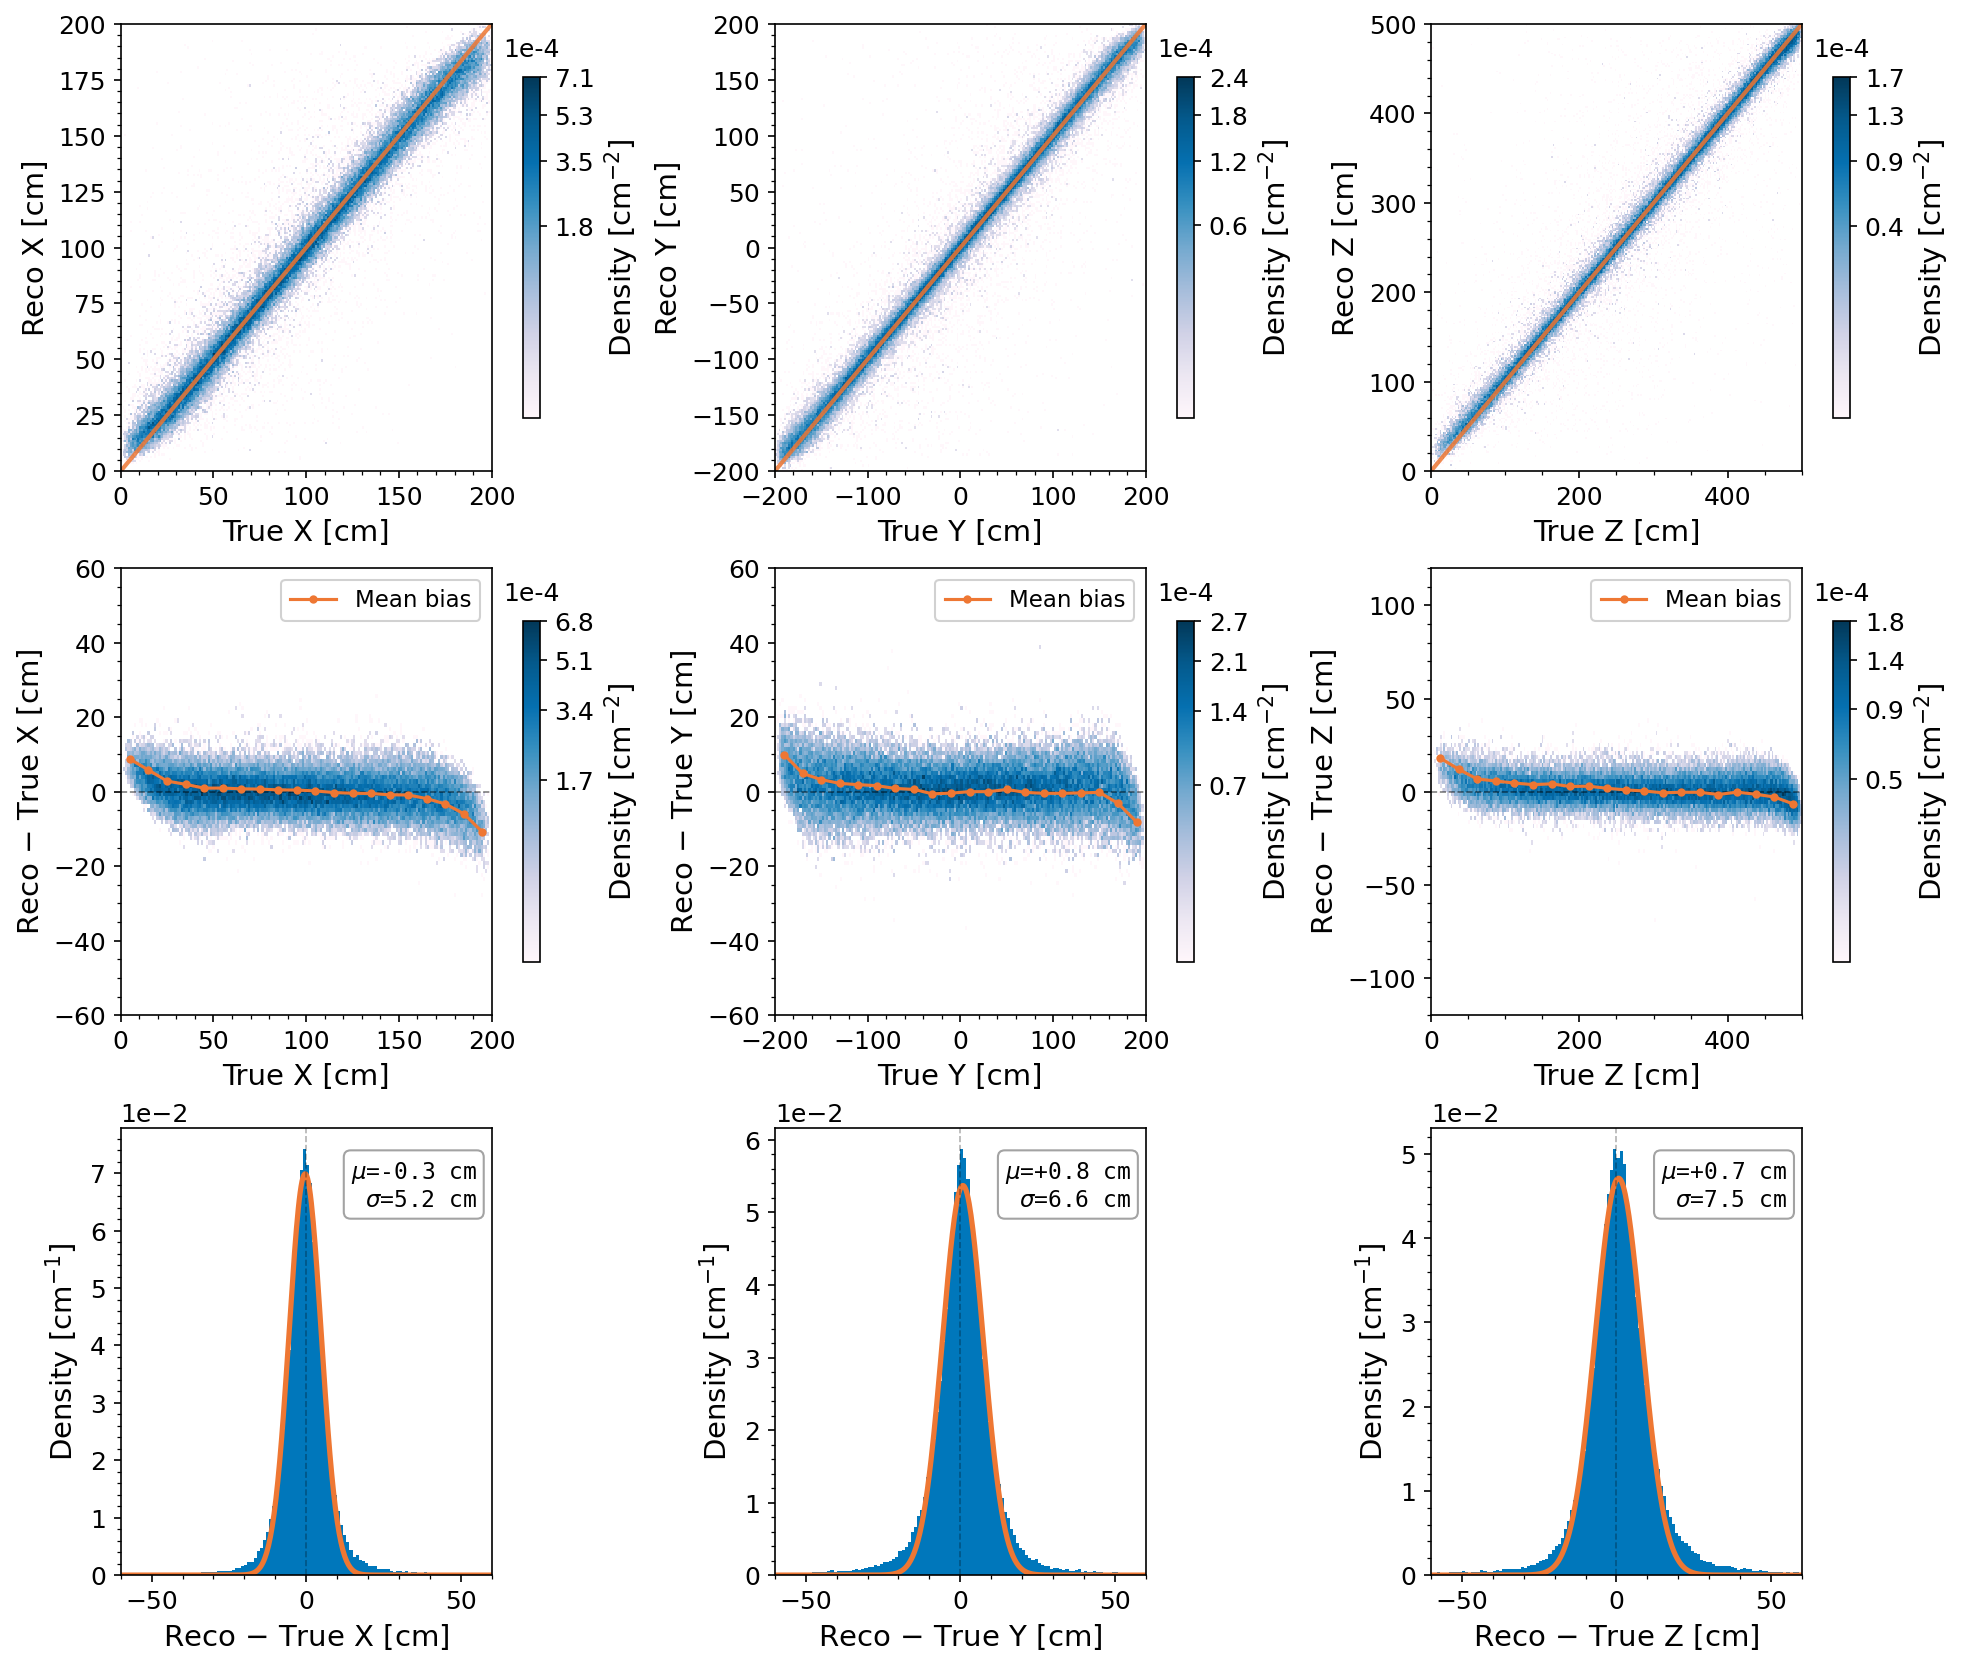

   RMSE: X=10.8  Y=19.1  Z=25.3 cm
   MAE:  X=6.1  Y=9.1  Z=11.2 cm


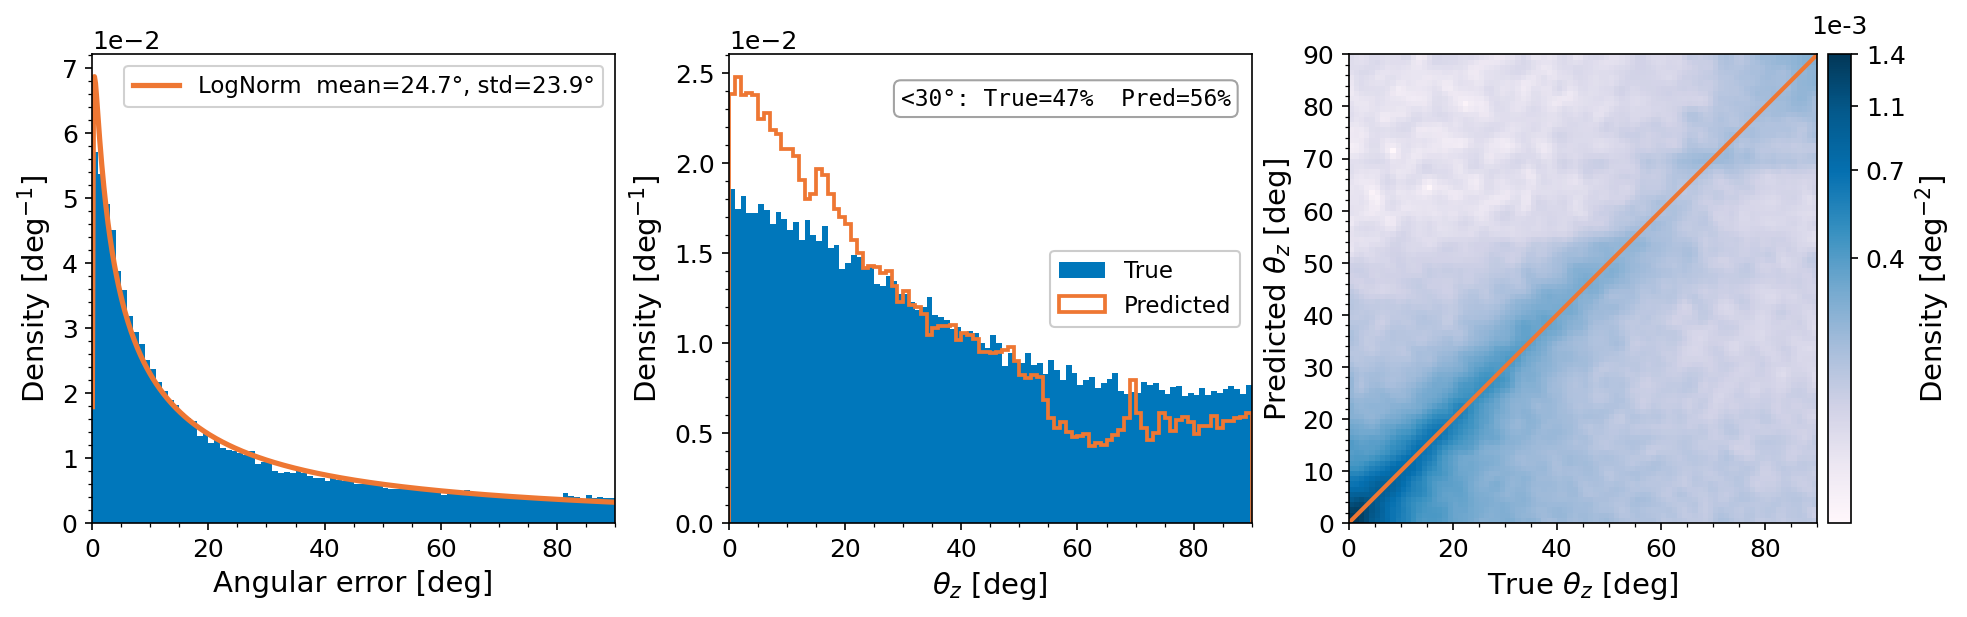


  VALIDATION SET RESULTS  (N=83,179)
  Position:
    X: bias=-0.34 cm, sigma=5.18 cm
    Y: bias=+0.83 cm, sigma=6.59 cm
    Z: bias=+0.68 cm, sigma=7.53 cm
  Direction:
    Mean=24.7°  Median=15.2°  <10°:39%  <20°:57%
    LogNorm fit: mu=3.92, sigma=2.21  =>  mean=24.7°, std=23.9°


In [214]:
# ── Run on validation set ─────────────────────────────────────────────────────
results_validation = evaluate_models(x_val, y_val, 'Validation Set', 'val')

## 11. Model Evaluation on Test Set


>> Making predictions on test set with both models...
   Predictions: 83,180 events
   Position  — mean 3D dist: 17.8 cm
   Direction — median error:  15.3 deg


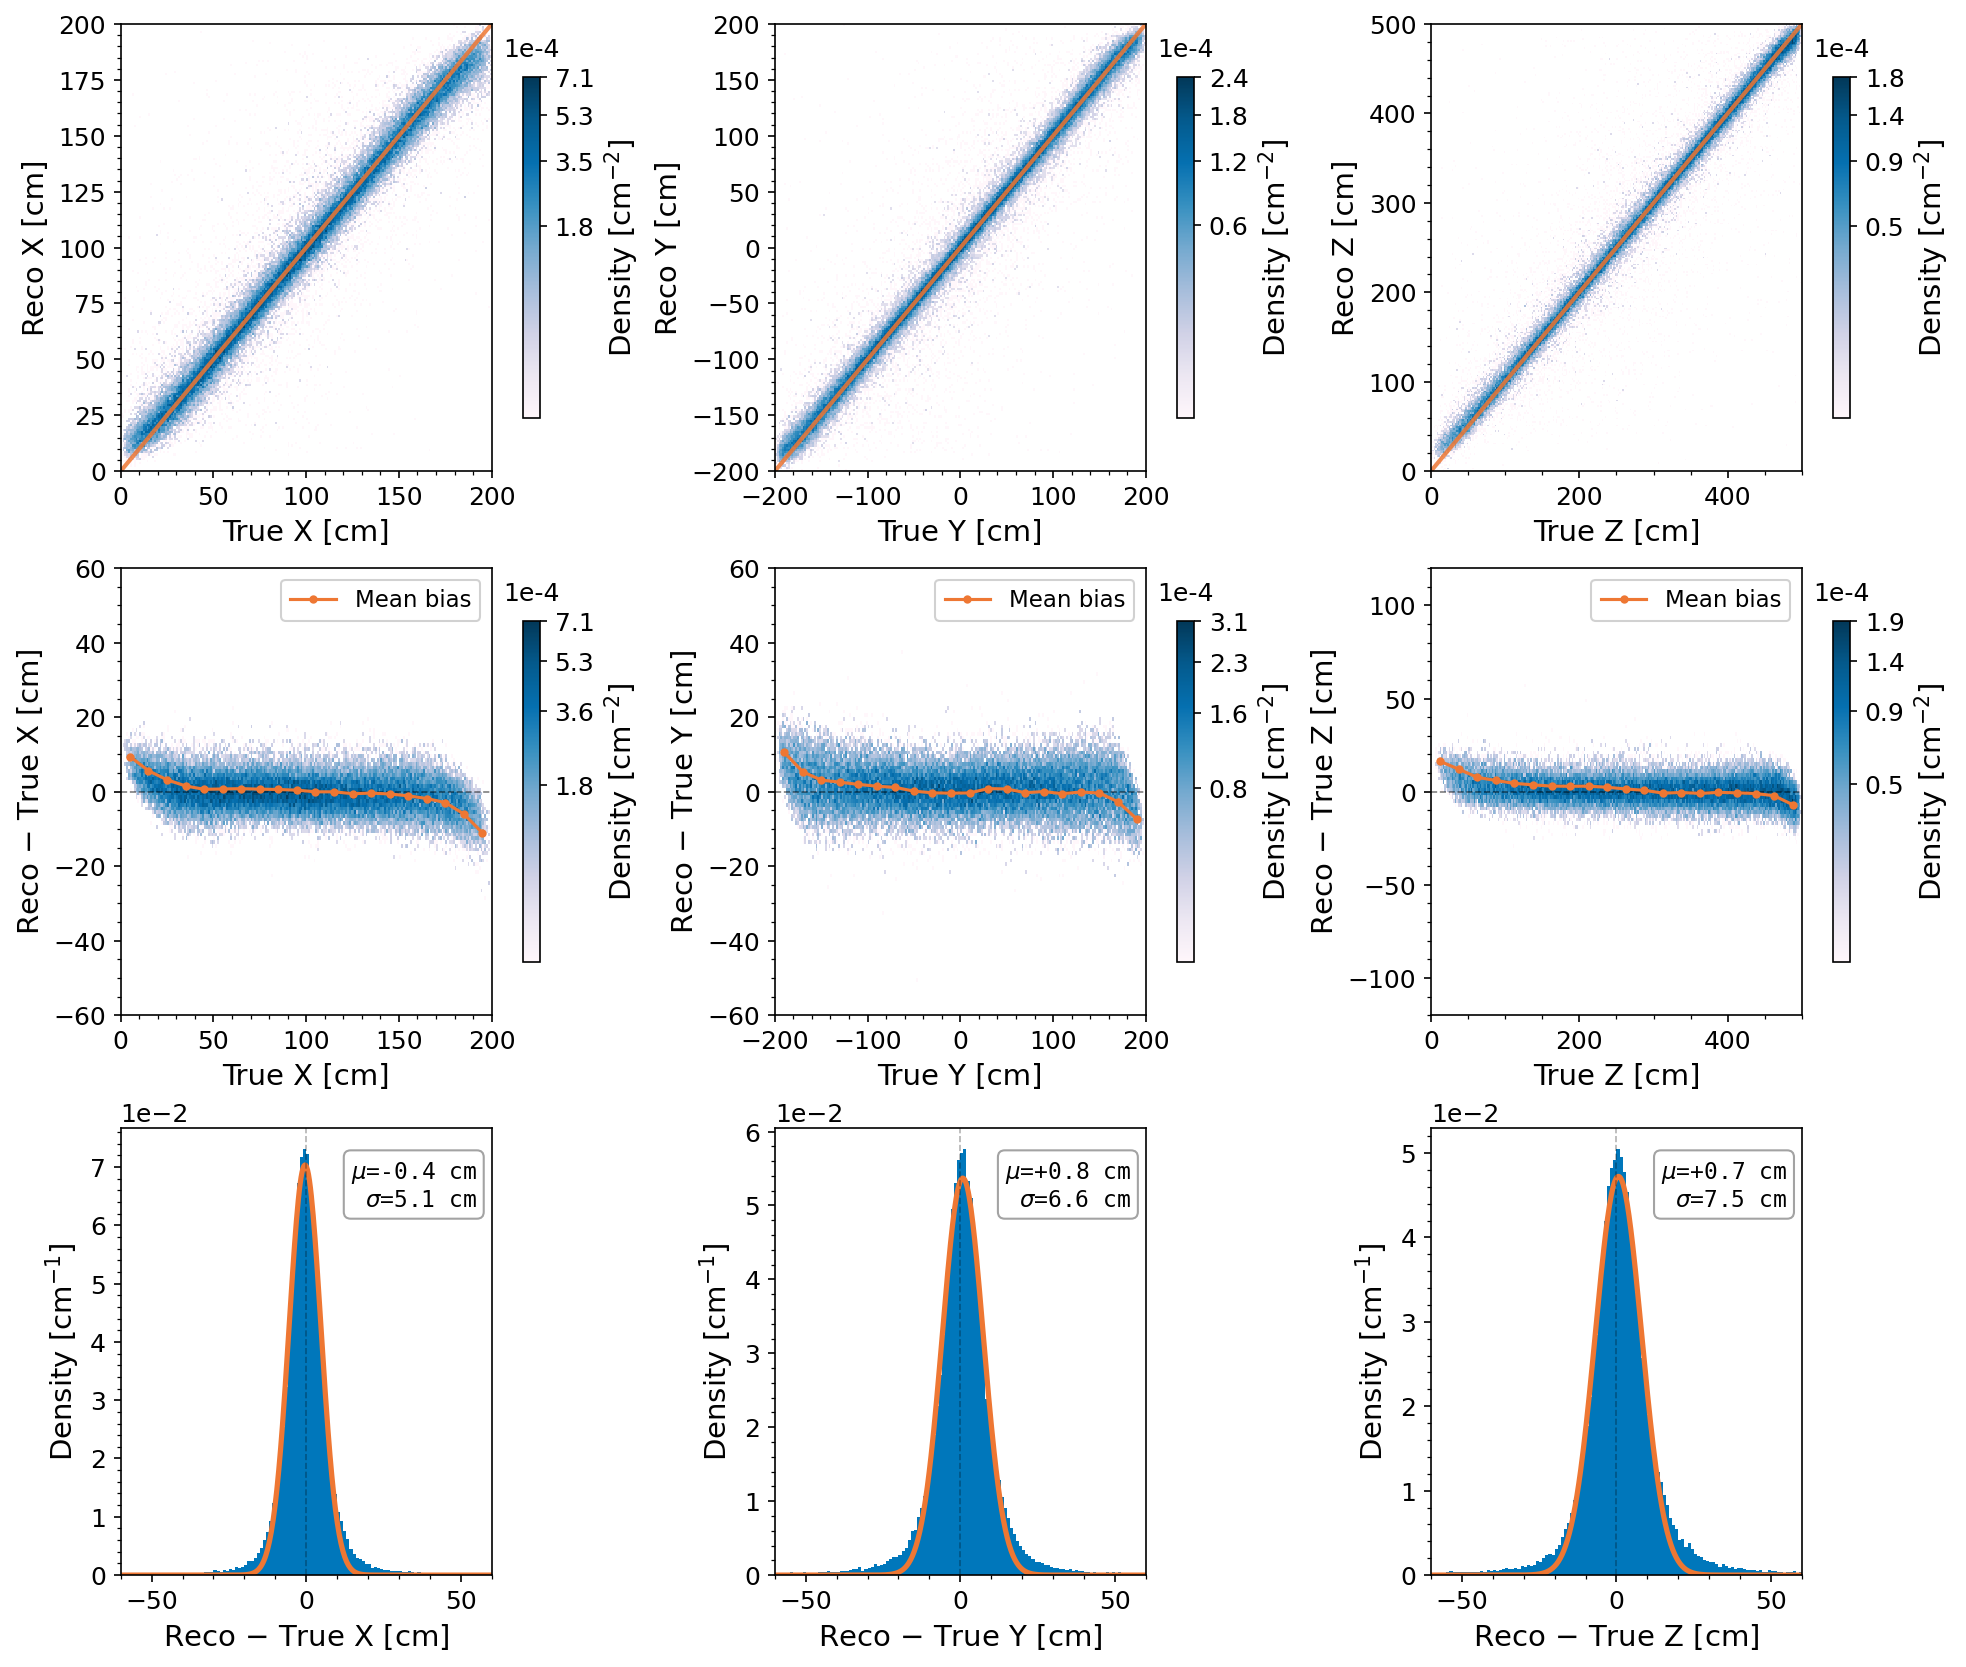

   RMSE: X=10.4  Y=18.5  Z=24.7 cm
   MAE:  X=6.0  Y=9.0  Z=11.1 cm


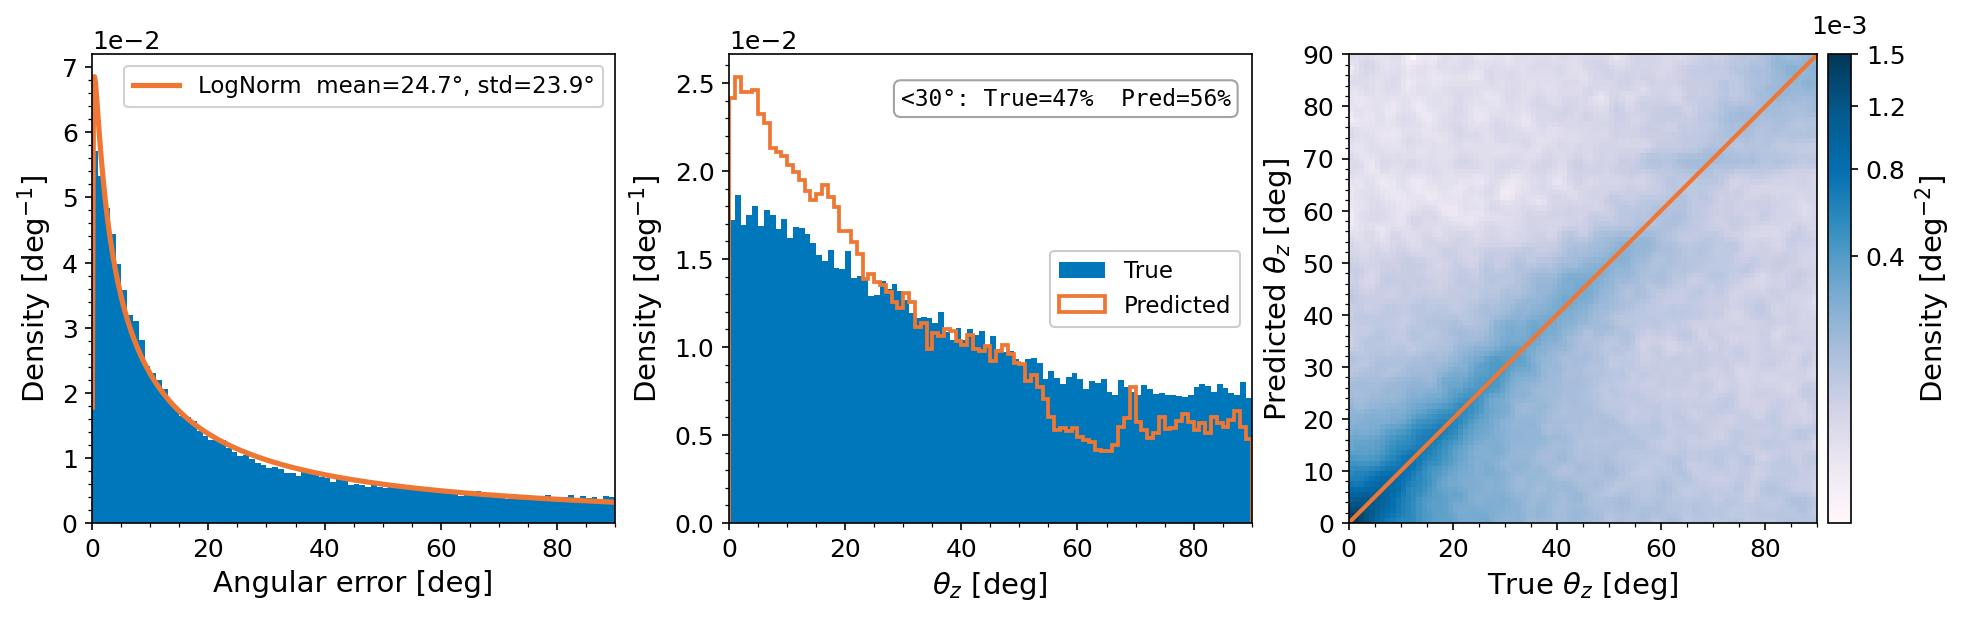


  TEST SET RESULTS  (N=83,180)
  Position:
    X: bias=-0.38 cm, sigma=5.14 cm
    Y: bias=+0.80 cm, sigma=6.62 cm
    Z: bias=+0.66 cm, sigma=7.48 cm
  Direction:
    Mean=24.7°  Median=15.3°  <10°:39%  <20°:57%
    LogNorm fit: mu=3.92, sigma=2.21  =>  mean=24.7°, std=23.9°


In [216]:
# ── Run on test set ────────────────────────────────────────────────────────────
results_test = evaluate_models(x_test_set, y_test_combined, 'Test Set', 'test')

## 12. Training Summary


In [217]:
print("=" * 60)
print("   TRAINING PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 60)

pos_names = ['X', 'Y', 'Z']

bias_results_val  = results_validation['bias_results']
bias_results_test = results_test['bias_results']

print(f"\n>> Dataset:")
print(f"   * Training events:   {len(y_train):,}")
print(f"   * Validation events: {len(y_val):,}")

print(f"\n>> Models saved:")
print(f"   * Position:  {pos_model_save_path}")
print(f"   * Direction: {dir_model_save_path}")

print(f"\n>> Validation performance:")
print(f"   * Final val loss (pos): {min(pos_history.history['val_loss']):.6f}")
print(f"   * Overall RMSE (3D):    {results_validation['overall_rmse']:.2f} cm")
for coord in pos_names:
    mean  = bias_results_val[coord]['mean']
    sigma = bias_results_val[coord]['sigma']
    print(f"   * {coord}: bias = {mean:+.2f} cm,  sigma = {sigma:.2f} cm")

print(f"\n>> Test performance:")
print(f"   * Overall RMSE (3D): {results_test['overall_rmse']:.2f} cm")
for coord in pos_names:
    mean  = bias_results_test[coord]['mean']
    sigma = bias_results_test[coord]['sigma']
    print(f"   * {coord}: bias = {mean:+.2f} cm,  sigma = {sigma:.2f} cm")

print(f"\n>> Direction (YZ plane, sign-invariant):")
print(f"   * Validation — mean: {results_validation['dir_stats']['mean']:.2f}°,  median: {results_validation['dir_stats']['median']:.2f}°")
print(f"   * Test        — mean: {results_test['dir_stats']['mean']:.2f}°,  median: {results_test['dir_stats']['median']:.2f}°")

# Clean up large arrays from memory
for _var in ['x_train', 'x_val', 'x_test_set', 'y_train', 'y_val', 'y_test_combined', 'images']:
    globals().pop(_var, None)
gc.collect()
print(f"\n>> Memory cleaned up")
print("=" * 60)


   TRAINING PIPELINE COMPLETED SUCCESSFULLY

>> Dataset:
   * Training events:   388,169
   * Validation events: 83,179

>> Models saved:
   * Position:  /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554/models/v0410_trained_w_388k_position/saved_model
   * Direction: /exp/sbnd/data/users/svidales/AI_nuvT_project_support/AA_FinalPlots/position/run_20260410_1554/models/v0411_trained_w_388k_direction_2d/saved_model

>> Validation performance:
   * Final val loss (pos): 0.000499
   * Overall RMSE (3D):    33.51 cm
   * X: bias = -0.34 cm,  sigma = 5.18 cm
   * Y: bias = +0.83 cm,  sigma = 6.59 cm
   * Z: bias = +0.68 cm,  sigma = 7.53 cm

>> Test performance:
   * Overall RMSE (3D): 32.58 cm
   * X: bias = -0.38 cm,  sigma = 5.14 cm
   * Y: bias = +0.80 cm,  sigma = 6.62 cm
   * Z: bias = +0.66 cm,  sigma = 7.48 cm

>> Direction (YZ plane, sign-invariant):
   * Validation — mean: 24.70°,  median: 15.22°
   * Test        — mean: 24.71°,  median: